# MERIT: Multi-Source Evaluation Suite
### Imperial College London | Final Year Project

This notebook orchestrates the empirical validation of the MERIT recruitment engine. It covers comparative ranking accuracy, runtime complexity, and spacetime resource allocation.

## 0. System Specification
Logging the benchmarking environment to provide context for runtime and spacetime results.

In [1]:
import platform
import psutil
import sys

def print_sys_info():
    print("="*60)
    print("BENCHMARKING ENVIRONMENT")
    print("="*60)
    print(f"OS: {platform.system()} {platform.release()} ({platform.version()})")
    print(f"Python Version: {sys.version}")
    print(f"Processor: {platform.processor()}")
    print(f"Cores: {psutil.cpu_count(logical=False)} Physical, {psutil.cpu_count(logical=True)} Logical")
    print(f"Total RAM: {psutil.virtual_memory().total / (1024**3):.2f} GB")
    print("="*60)

print_sys_info()

BENCHMARKING ENVIRONMENT
OS: Windows 10 (10.0.26200)
Python Version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Processor: AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD
Cores: 8 Physical, 16 Logical
Total RAM: 63.15 GB


## Setup & Path Integration

In [2]:
import os
import contextlib
from IPython.display import Image, display

# Add subdirectories to path to allow direct imports
root_dir = os.getcwd()
sys.path.append(os.path.join(root_dir, '01-comparative_study'))
sys.path.append(os.path.join(root_dir, '02-runtime_study'))
sys.path.append(os.path.join(root_dir, '03-spacetime_study'))

@contextlib.contextmanager
def working_directory(path):
    """Utility to temporarily change the working directory for sub-study runners."""
    prev_cwd = os.getcwd()
    os.chdir(path)
    try:
        yield
    finally:
        os.chdir(prev_cwd)

print("Environment Initialised.")

Environment Initialised.


## 1. Study 01: Comparative Evaluation (Adversarial Benchmarking)
This study evaluates the ranking accuracy of MERIT against Traditional and Modern AI ATS models using adversarial personas.

Running Stage 1: Baseline ATS...
Running Traditional ATS Baseline Study...
[DATA LOAD] Reading 10 candidates from: c:\Users\Rayan\OneDrive - Imperial College London\4th year\FYP\MERIT\evaluation\01-comparative_study\test_data\candidates


Scoring Candidates (Baseline ATS):   0%|          | 0/10 [00:00<?, ?it/s]

[SUCCESS] Results exported to c:\Users\Rayan\OneDrive - Imperial College London\4th year\FYP\MERIT\evaluation\01-comparative_study\output/baseline_rankings.csv

Running Stage 2: Modern AI ATS...
Running Modern AI ATS (Semantic) Study...
[DATA LOAD] Reading 10 candidates from: c:\Users\Rayan\OneDrive - Imperial College London\4th year\FYP\MERIT\evaluation\01-comparative_study\test_data\candidates


Scoring Candidates (Modern AI ATS):   0%|          | 0/10 [00:00<?, ?it/s]

[SUCCESS] Results exported to c:\Users\Rayan\OneDrive - Imperial College London\4th year\FYP\MERIT\evaluation\01-comparative_study\output/modern_ai_ats_rankings.csv

Running Stage 3: MERIT (CV-Only Ablation)...
Running MERIT (CV-Only) Ablation Study...
[DATA LOAD] Reading 10 candidates from: c:\Users\Rayan\OneDrive - Imperial College London\4th year\FYP\MERIT\evaluation\01-comparative_study\test_data\candidates


Scoring Candidates (MERIT CV-Only):   0%|          | 0/10 [00:00<?, ?it/s]

[SUCCESS] Results exported to c:\Users\Rayan\OneDrive - Imperial College London\4th year\FYP\MERIT\evaluation\01-comparative_study\output/merit_cv_only_rankings.csv

Running Stage 4: MERIT (Full Multi-Source Integration)...
Running MERIT (Full Multi-Source) Study...
[DATA LOAD] Reading 10 candidates from: c:\Users\Rayan\OneDrive - Imperial College London\4th year\FYP\MERIT\evaluation\01-comparative_study\test_data\candidates


Scoring Candidates (Multi-Source):   0%|          | 0/10 [00:00<?, ?it/s]

[SUCCESS] Results exported to c:\Users\Rayan\OneDrive - Imperial College London\4th year\FYP\MERIT\evaluation\01-comparative_study\output/merit_all_sources_rankings.csv

Generating Visualisations...
[SUCCESS] rank_displacement_holistic.png generated.
[SUCCESS] rank_displacement_successes.png generated.
[SUCCESS] rank_displacement_limitations.png generated.
[SUCCESS] rank_displacement_edge_cases.png generated.

Visualising Results:


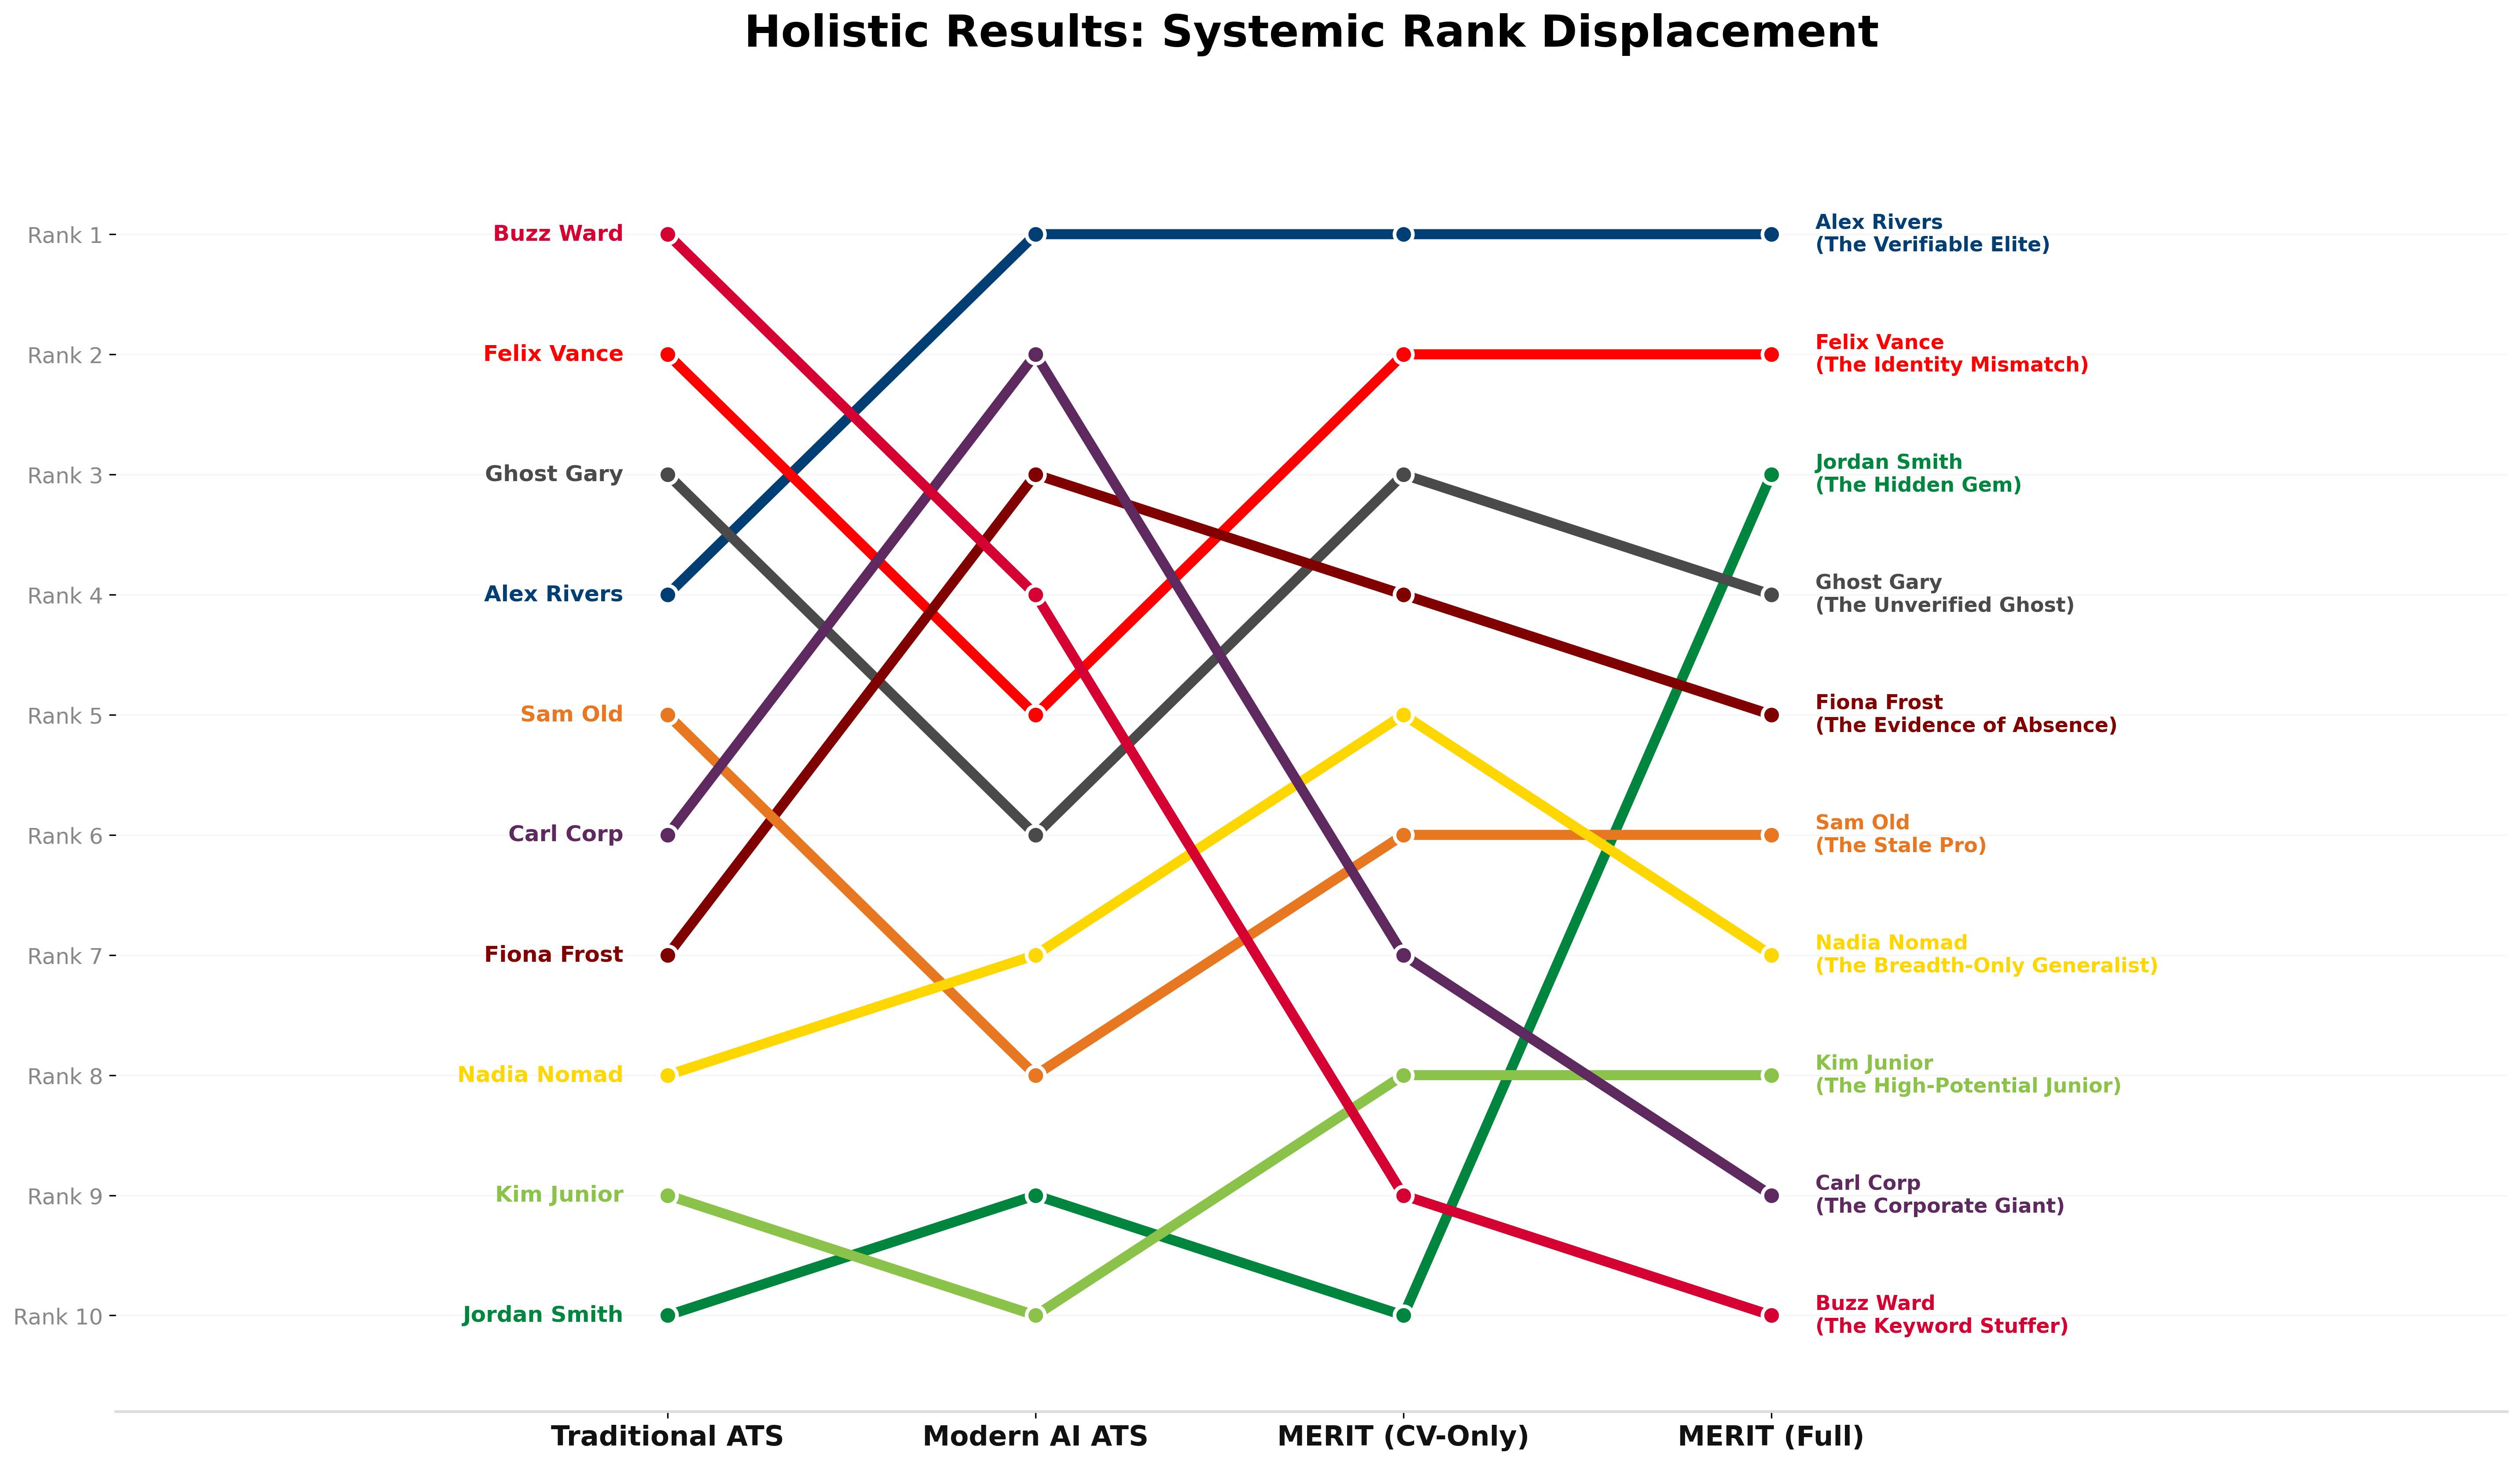

In [3]:
from baseline_ats import run_baseline_study
from modern_ai_ats import run_ai_study
from merit_cv_only import run_cv_ablation_study
from merit_all_sources import run_full_study
from generate_visualisations import generate_evaluation_visualisations

study_01_dir = os.path.join(root_dir, '01-comparative_study')

with working_directory(study_01_dir):
    print("Running Stage 1: Baseline ATS...")
    run_baseline_study()
    
    print("\nRunning Stage 2: Modern AI ATS...")
    run_ai_study()
    
    print("\nRunning Stage 3: MERIT (CV-Only Ablation)...")
    run_cv_ablation_study()
    
    print("\nRunning Stage 4: MERIT (Full Multi-Source Integration)...")
    run_full_study()
    
    print("\nGenerating Visualisations...")
    generate_evaluation_visualisations()

print("\nVisualising Results:")
display(Image(filename='01-comparative_study/output/rank_displacement_holistic.png', width=700))

## 2. Study 02: Runtime Complexity
Evaluation of ranking latency scaling from $N=10$ to $N=500$ candidates.

Running Runtime Complexity Study...
Initialising engines...

Benchmarking with 10 candidates...
[DATA LOAD] Reading 10 candidates from: c:\Users\Rayan\OneDrive - Imperial College London\4th year\FYP\MERIT\evaluation\02-runtime_study\test_data\candidates


Traditional ATS:   0%|          | 0/10 [00:00<?, ?it/s]

Modern AI ATS:   0%|          | 0/10 [00:00<?, ?it/s]

MERIT CV-Only:   0%|          | 0/10 [00:00<?, ?it/s]

MERIT Full:   0%|          | 0/10 [00:00<?, ?it/s]

...

Modern AI ATS:   0%|          | 0/500 [00:00<?, ?it/s]

MERIT CV-Only:   0%|          | 0/500 [00:00<?, ?it/s]

MERIT Full:   0%|          | 0/500 [00:00<?, ?it/s]

MERIT Explainable:   0%|          | 0/500 [00:00<?, ?it/s]


--- Runtime Study Complete ---
 Candidates  Traditional ATS (s)  Modern AI ATS (s)  MERIT CV-Only (s)  MERIT Full (s)  MERIT Explainable (s)
         10               0.0080             4.7070             0.0377          0.0499                 0.2388
         50               0.0181            22.2429             0.1675          0.2863                 1.2227
        100               0.0301            41.1023             0.2302          0.3070                 1.7817
        200               0.0437            73.7906             0.7014          0.7991                 4.6400
        500               0.0978           173.8721             1.1631          1.3782                 8.6273

Results saved to c:\Users\Rayan\OneDrive - Imperial College London\4th year\FYP\MERIT\evaluation\02-runtime_study\output/runtime_results.csv

Results saved to c:\Users\Rayan\OneDrive - Imperial College London\4th year\FYP\MERIT\evaluation\02-runtime_study\output/runtime_results.csv
[SUCCESS] Runtime plot s

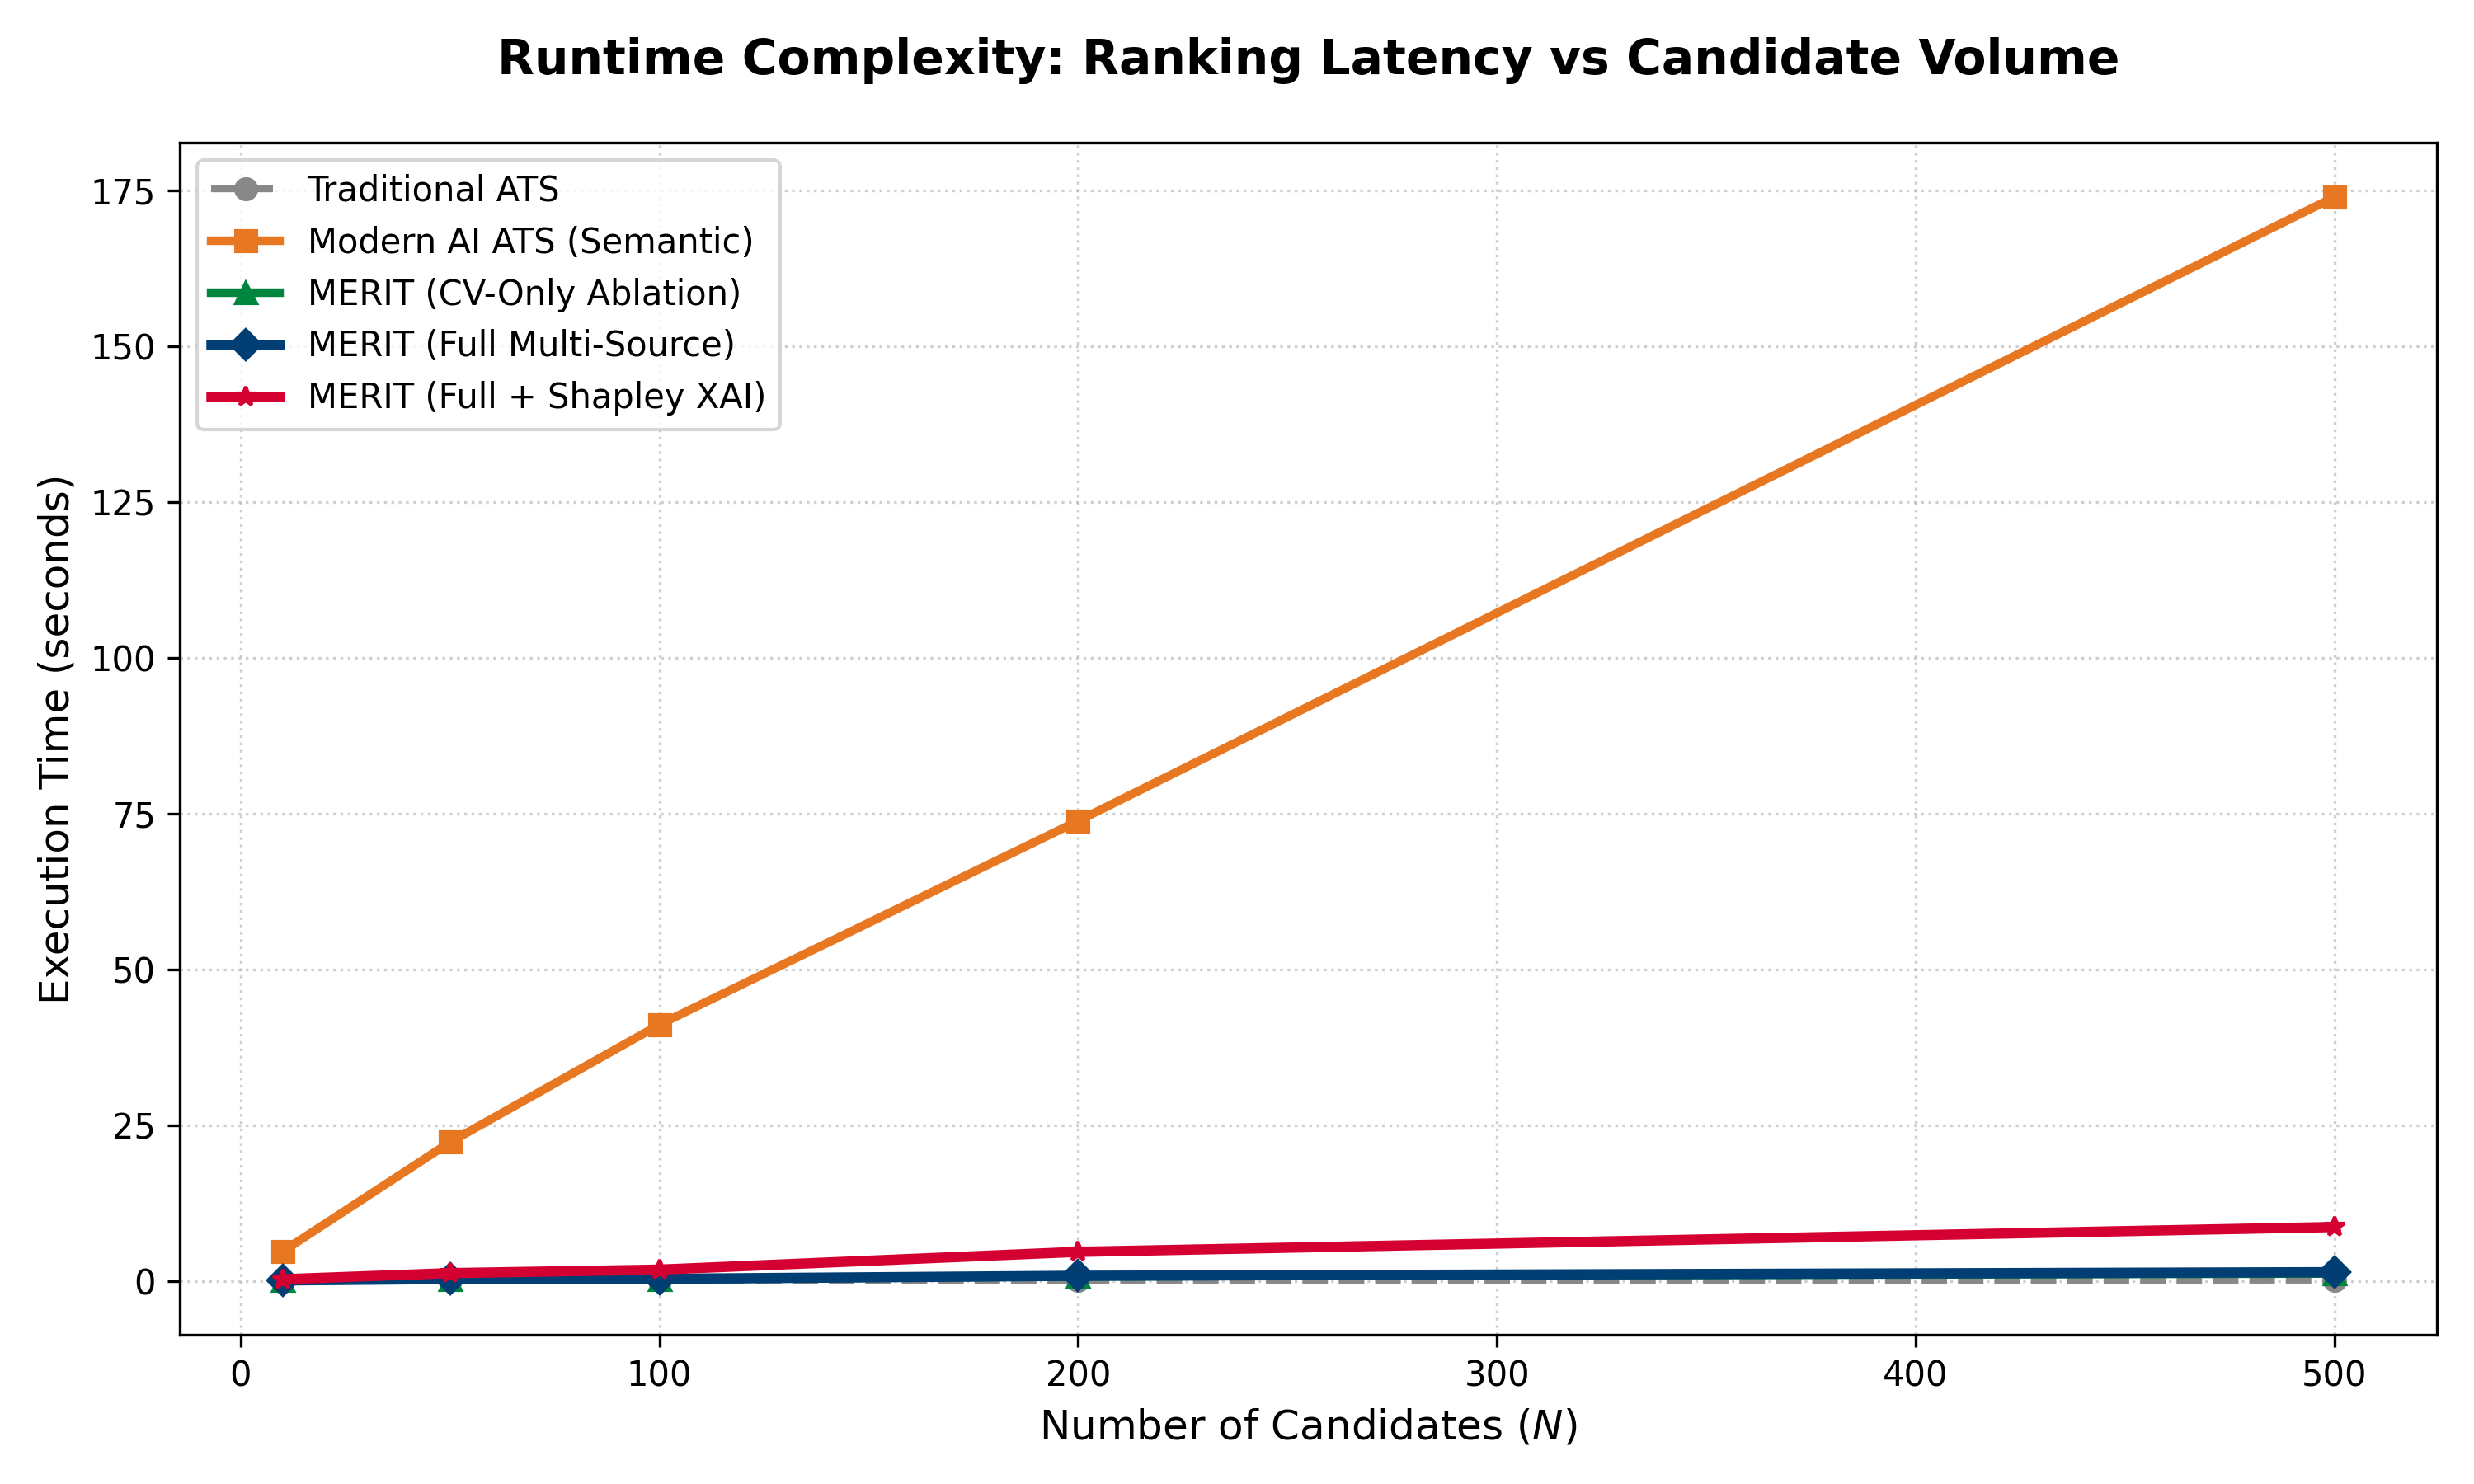

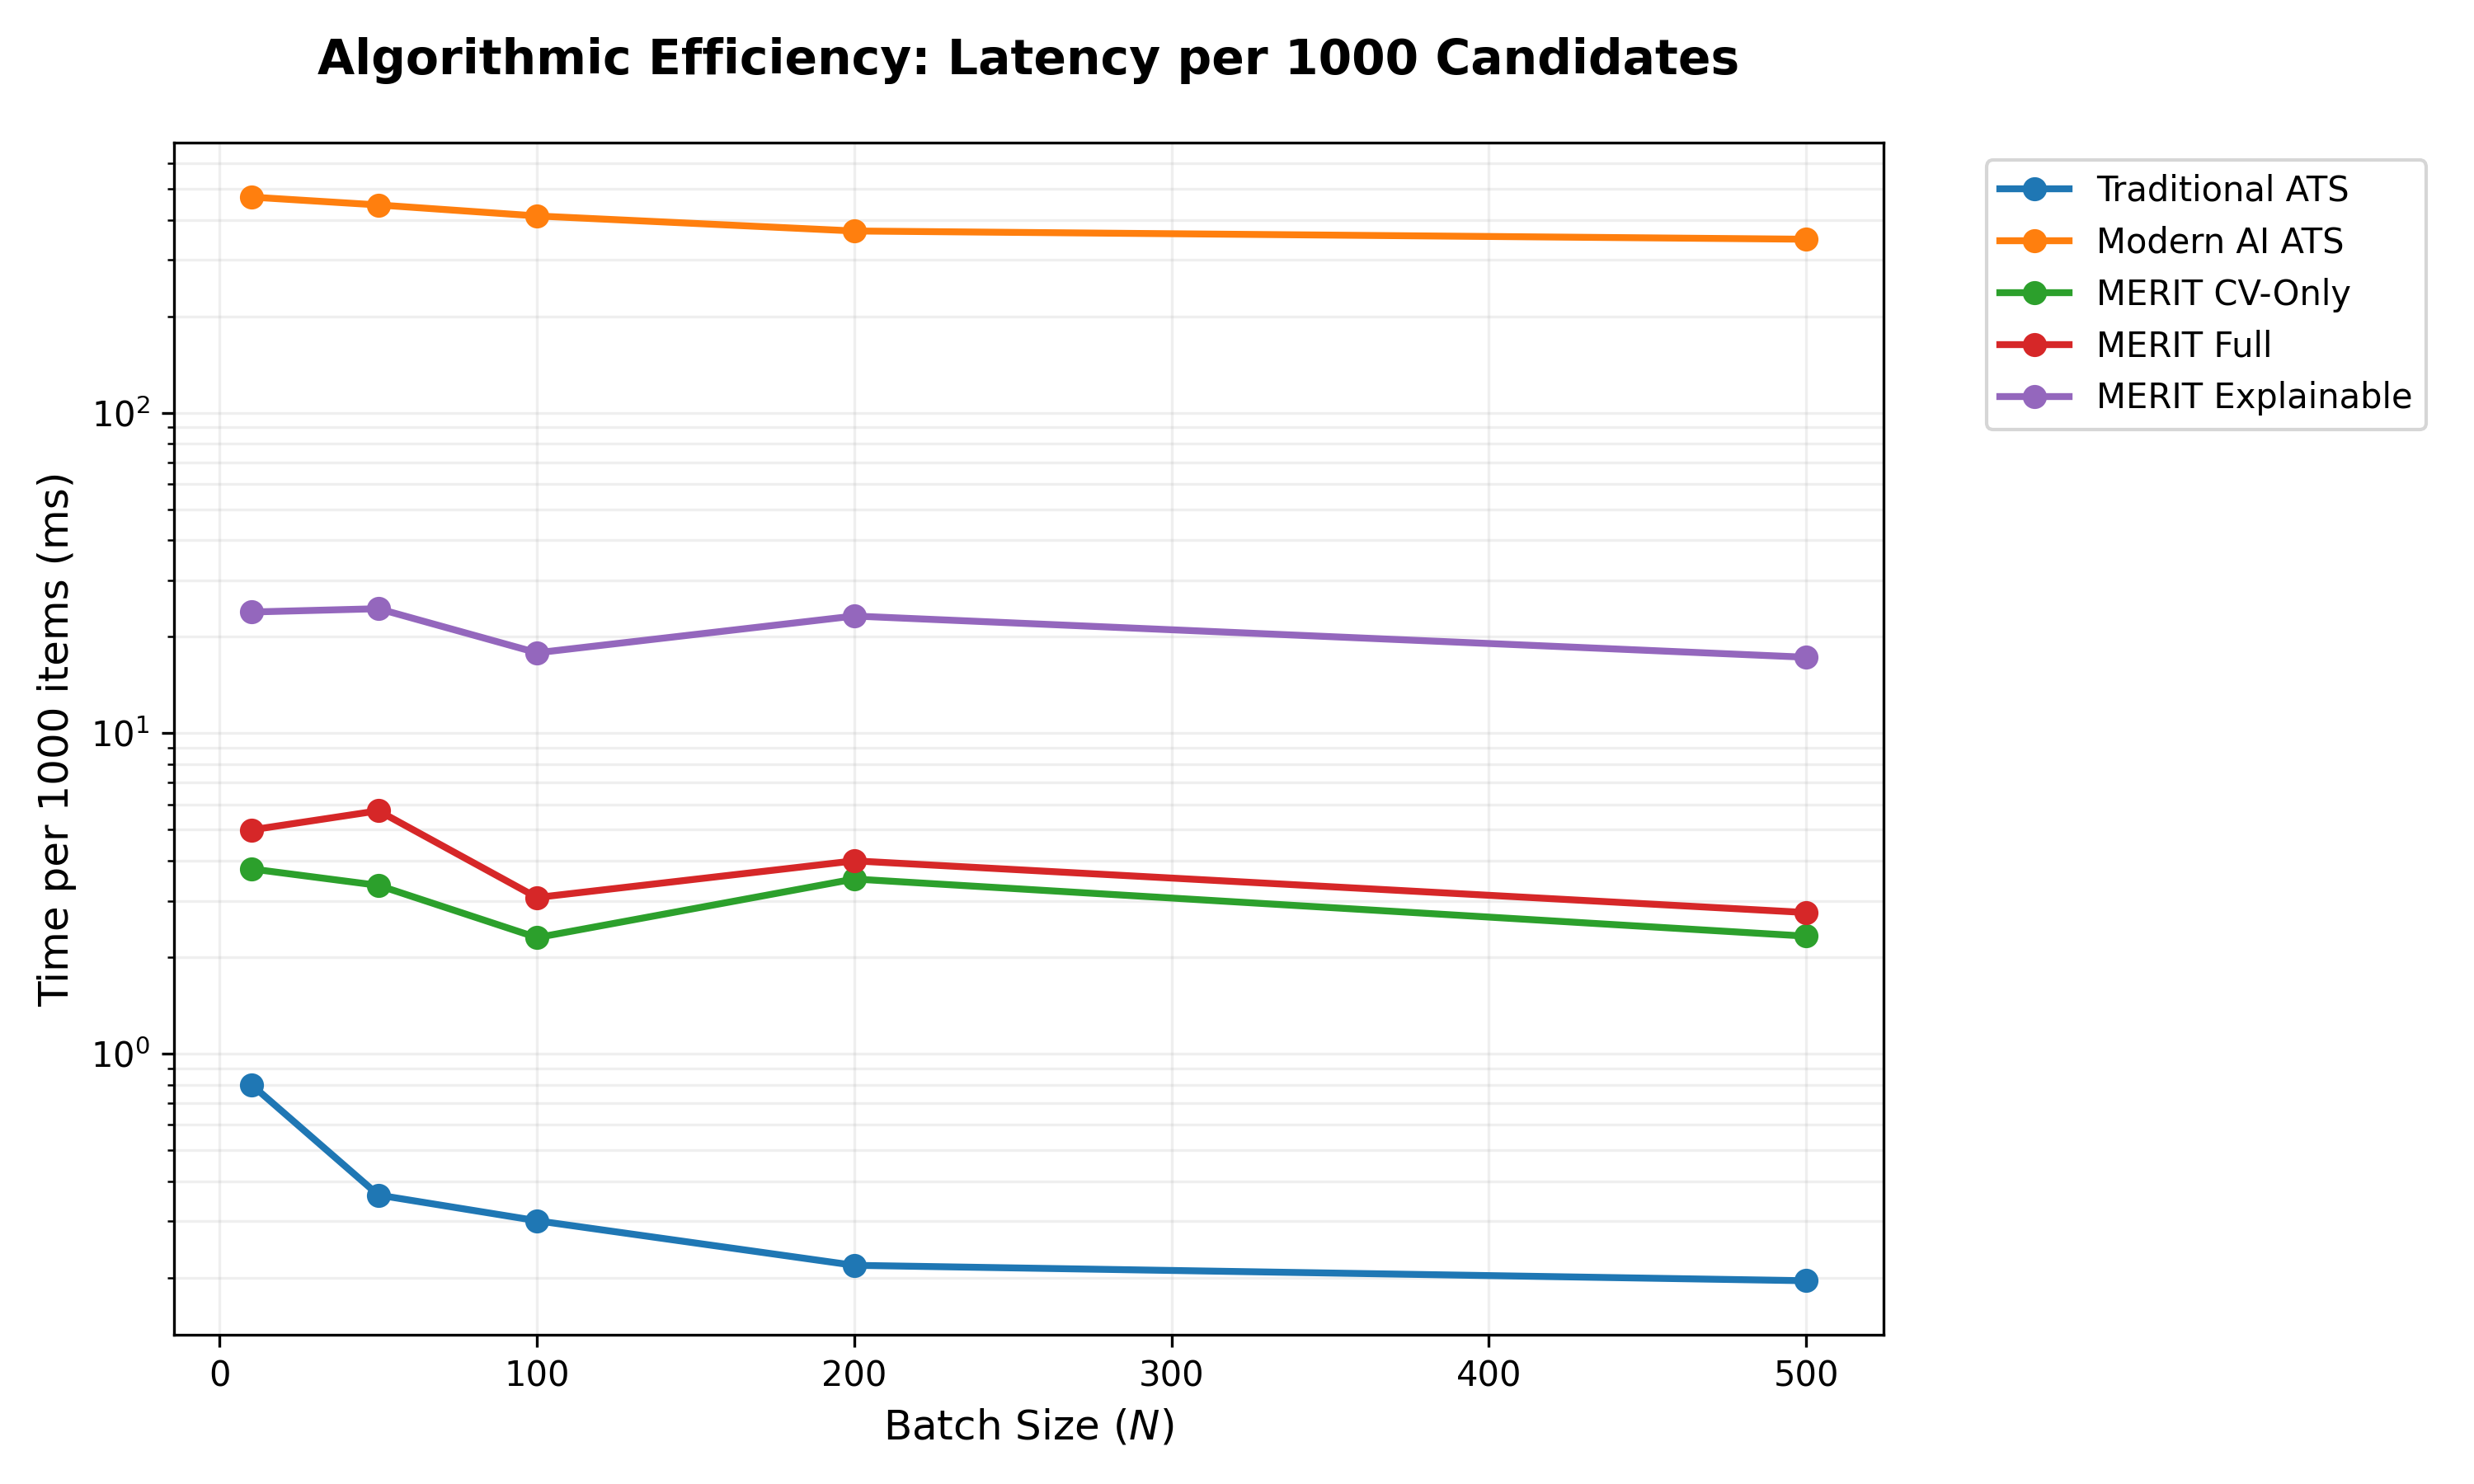

In [4]:
from run_runtime import benchmark_runtime

study_02_dir = os.path.join(root_dir, '02-runtime_study')

with working_directory(study_02_dir):
    print("Running Runtime Complexity Study...")
    benchmark_runtime()
    # Explicitly generate plots in notebook context
    from generate_runtime_visualisations import generate_runtime_plots
    generate_runtime_plots()
    # Explicitly generate plots in notebook context
    from generate_runtime_visualisations import generate_runtime_plots
    generate_runtime_plots()

print("\nPerformance Curves:")
display(Image(filename='02-runtime_study/output/runtime_complexity_plot.png', width=700))
display(Image(filename='02-runtime_study/output/runtime_efficiency_log.png', width=700))

## 3. Study 03: Spacetime Complexity
Analysis of static engine footprint and incremental batch memory overhead.

> [!IMPORTANT]
> **Benchmarking Methodology Note:**
> Memory (Spacetime) benchmarking is highly sensitive to the Jupyter environment's shared process memory. 
> To ensure "Glass-Box" integrity and capture the most accurate resource allocation profiles, it is **strongly recommended** to execute this study from a standalone terminal:
> 
> ```powershell
> cd evaluation/03-spacetime_study
> python run_spacetime.py
> ```
> 
> This isolates the benchmarking process from the notebook's pre-loaded modules and ensures clean baseline measurements.


[SUCCESS] Spacetime composite plot saved to c:\Users\Rayan\OneDrive - Imperial College London\4th year\FYP\MERIT\evaluation\03-spacetime_study\output/spacetime_complexity_composite.png

Resource Allocation Profile:


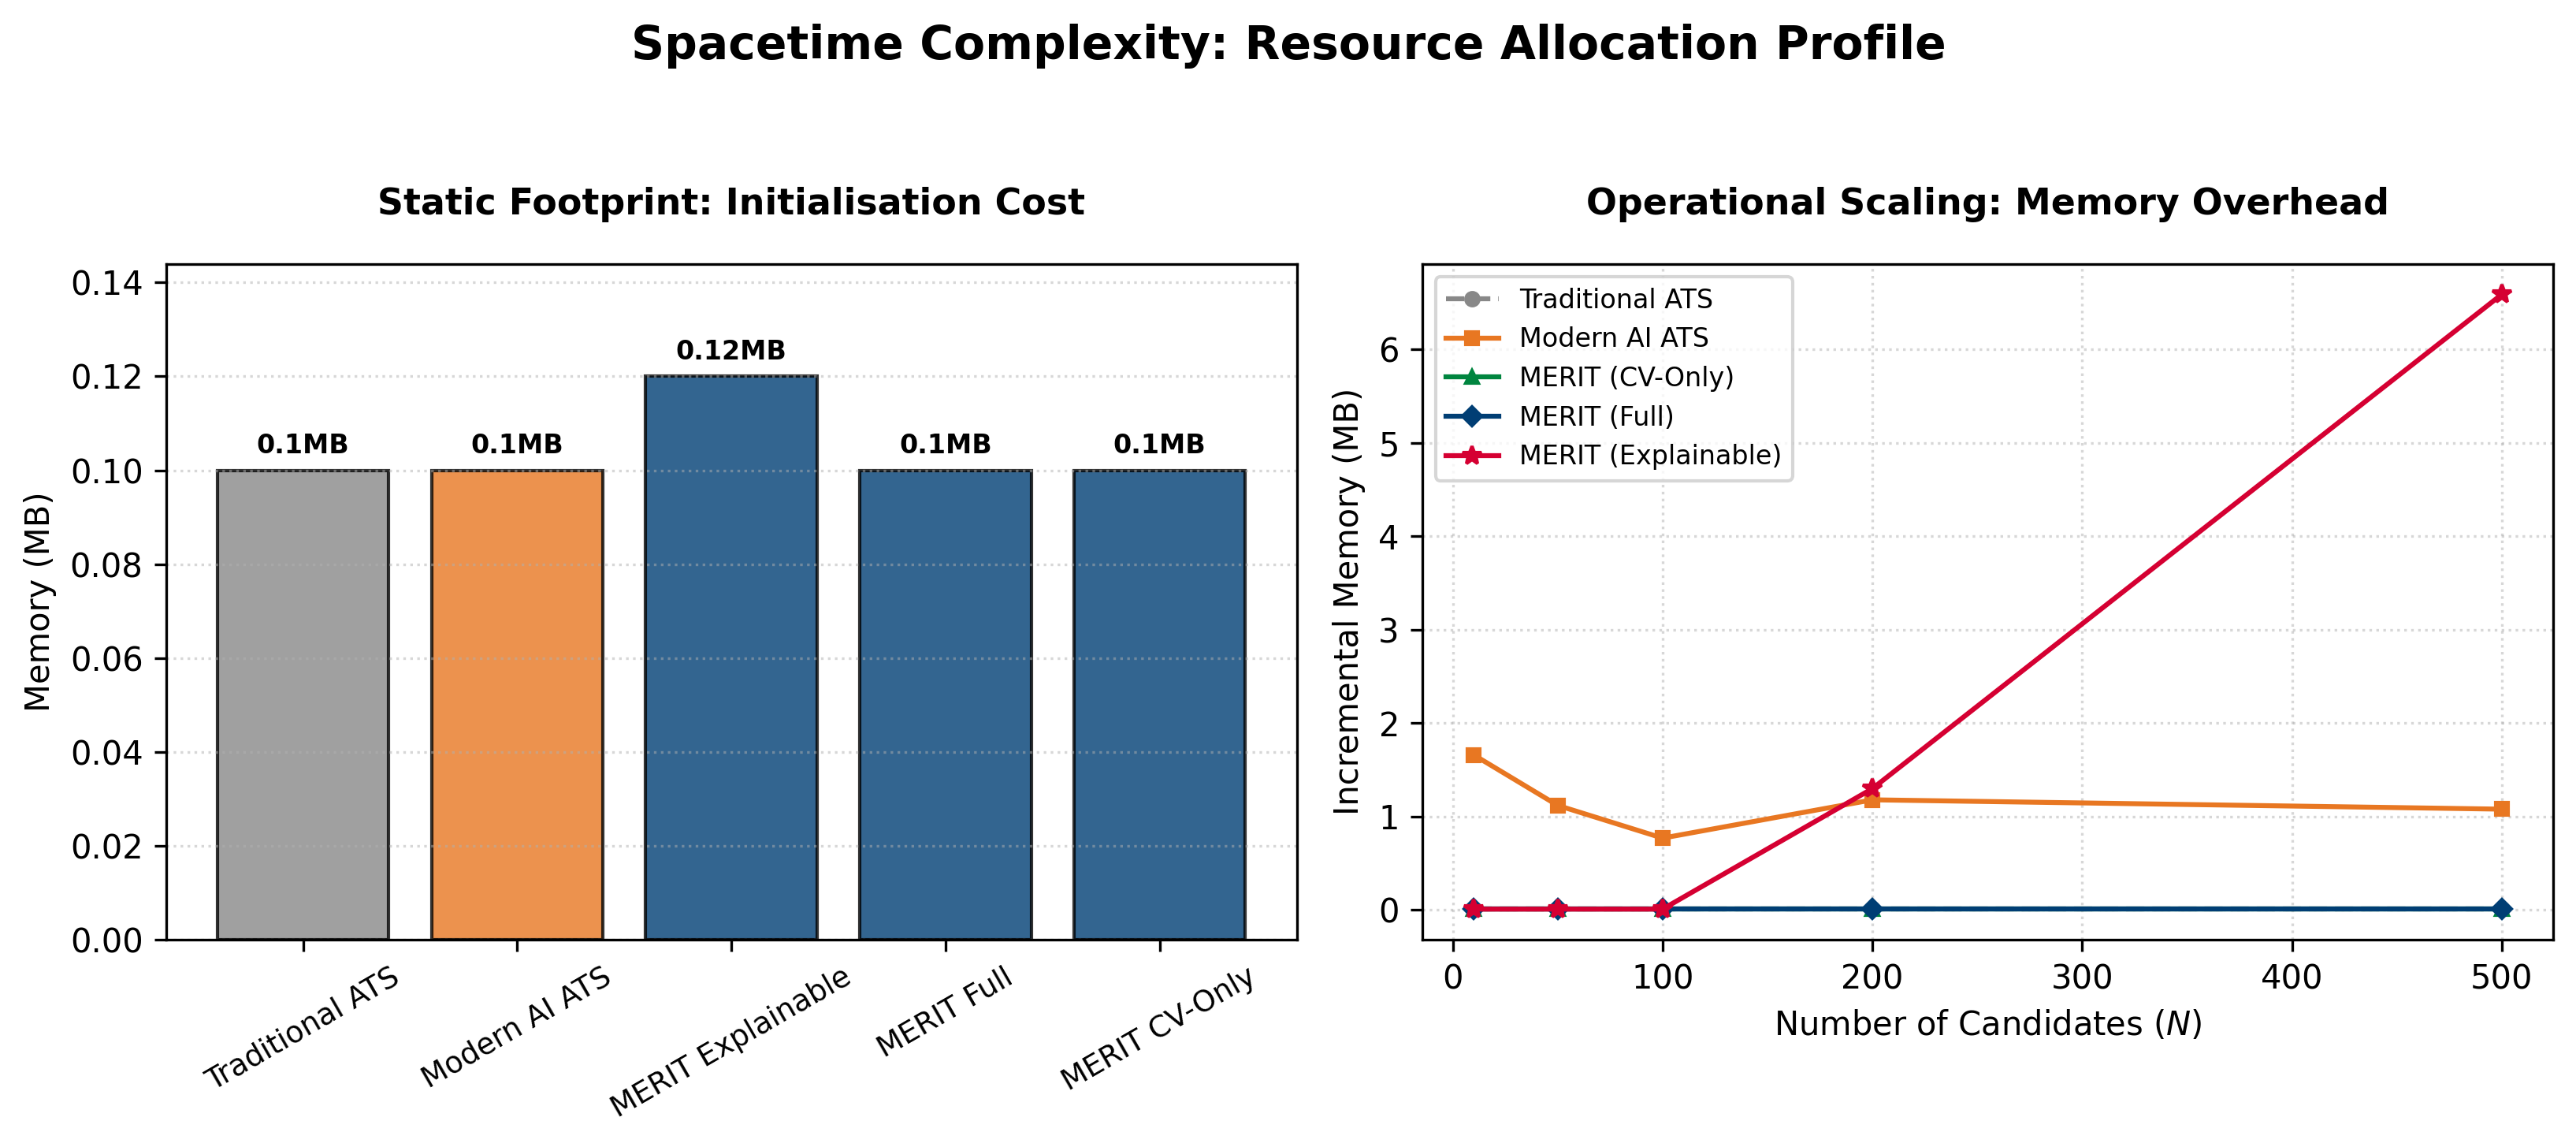

In [5]:
from run_spacetime import benchmark_spacetime

study_03_dir = os.path.join(root_dir, '03-spacetime_study')

# NOTE: This benchmark will not be as accurate from a jupyter notebook
# with working_directory(study_03_dir):
#     print("Running Spacetime Complexity Study...")
#     benchmark_spacetime()
# Explicitly generate plots in notebook context
from generate_spacetime_visualisations import generate_spacetime_plots
generate_spacetime_plots()

print("\nResource Allocation Profile:")
display(Image(filename='03-spacetime_study/output/spacetime_complexity_composite.png', width=700))

## 4. Study 04: IR Parser Accuracy (Information Retrieval)
This study evaluates the precision, recall, and F1-score of the core CV parser against a 'Ground Truth' dataset of 15 diverse technical resumes.

Running IR Parser Accuracy Test...
Extracting data from 15 resumes...
  [SUCCESS] 001_Milton_Uati_Junior_Software_Engineer.pdf
  [SUCCESS] 003_Henriette_Romero_Senior_Software_Engineer.pdf
  [SUCCESS] 005_Lihna_Deli_Principal_Software_Engineer.pdf
  [SUCCESS] 006_Piet_Burduja_Junior_Frontend_Engineer.pdf
  [SUCCESS] 0105_Sven_Kramer_Staff_DevOps_Engineer.pdf
  [SUCCESS] 0106_Moa_Lundh_Principal_Data_Engineer.pdf
  [SUCCESS] 0107_Takahiro_Hirano_Intern_Machine_Learning_Engineer.pdf
  [SUCCESS] 010_Kevin_Jawad_Principal_Frontend_Engineer.pdf
  [SUCCESS] 011_Yusuf_Nilsson_Junior_Backend_Engineer.pdf
  [SUCCESS] 0121_Arvid_Sandberg_Mid-Level_Quantitative_Developer.pdf
  [SUCCESS] 0128_Daniel_Miles_Senior_NLP_Engineer.pdf
  [SUCCESS] 0138_Aisling_Hunt_Junior_Data_Scientist.pdf
  [SUCCESS] 0142_Brooklyn_Lane_Principal_AR_VR_Developer.pdf
  [SUCCESS] 0147_Greetje_Schipper_Staff_Technical_Writer__Developer_Tools_.pdf
  [SUCCESS] 015_Patricia_Al-Bahar_Principal_Backend_Engineer.pdf

--- IR Pars

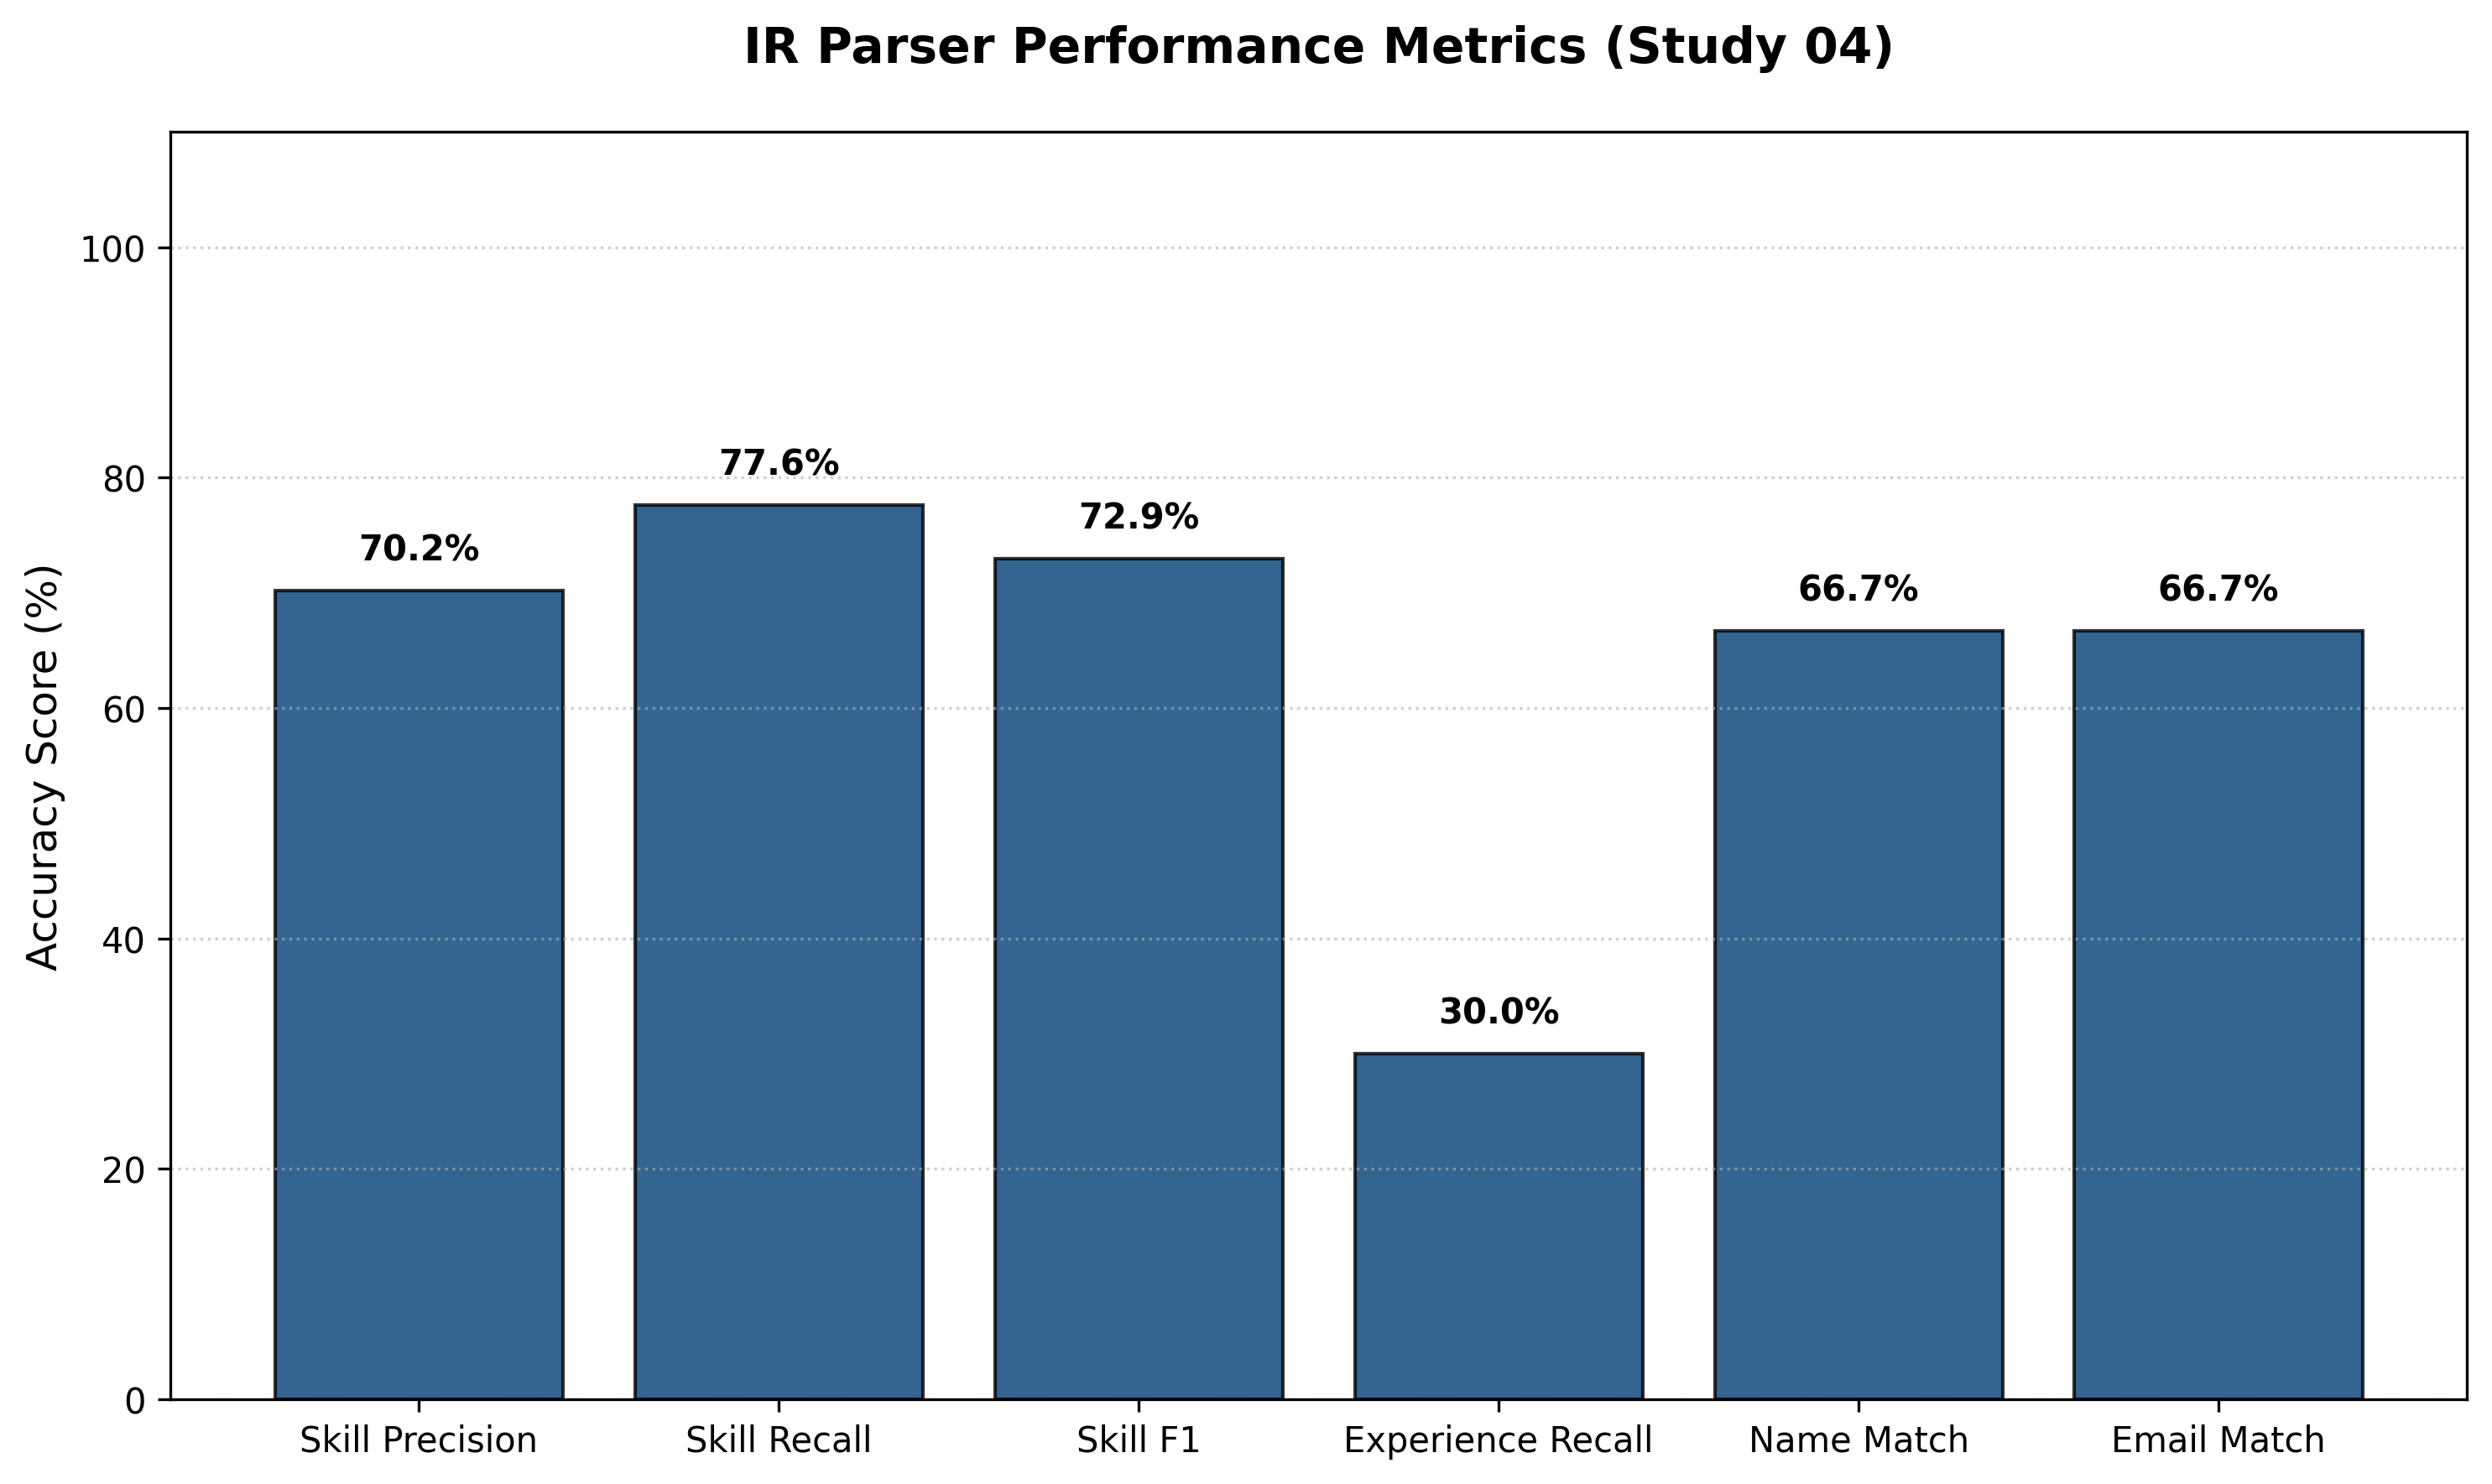

In [6]:
study_04_dir = os.path.join(root_dir, '04-ir_parser_test')

with working_directory(study_04_dir):
    print("Running IR Parser Accuracy Test...")
    
    from run_extraction import run_extraction
    run_extraction()
    
    from run_accuracy_test import run_test
    run_test()
    
    from generate_ir_visualisations import generate_accuracy_plots
    generate_accuracy_plots()

print("\nParser Accuracy Metrics:")
display(Image(filename='04-ir_parser_test/output/ir_parser_accuracy.png', width=750))

## 5. Study 05: JD Parser Accuracy
This study evaluates the extraction accuracy for Job Descriptions, focusing on titles, company names, and technical skill requirements.

Running JD Parser Accuracy Test...
--- Phase 1: JD Information Extraction ---
Extracting data from 15 Job Descriptions...


 27%|██▋       | 4/15 [00:00<00:01,  7.78it/s]Cannot set gray stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid float value
 33%|███▎      | 5/15 [00:00<00:01,  8.06it/s]Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
 60%|██████    | 9/15 [00:01<00:00,  7.66it/s]Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
 67%|██████▋   | 10/15 [00:01<00:00,  6.96it/s]Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could get FontBBox from font descriptor because None cannot be parsed as 4 floats
 87%|████████▋ | 13/15 [00:01<00:00,  7.39it/s]Cannot set gray stroke color because /'P3' is an invalid float value
Cannot set gray non-stroke color because /'P3' is an invalid floa


--- Phase 2: Accuracy Benchmarking ---

--- IR Parser Accuracy Results ---
Skill Precision      0.701566
Skill Recall         0.776375
Skill F1             0.729408
Experience Recall    0.300000
Name Match           0.666667
Email Match          0.666667
dtype: float64

Detailed report saved to c:\Users\Rayan\OneDrive - Imperial College London\4th year\FYP\MERIT\evaluation\04-ir_parser_test\output/accuracy_summary.csv

--- Phase 3: Visualization Generation ---
[SUCCESS] JD Parser Accuracy plot saved to c:\Users\Rayan\OneDrive - Imperial College London\4th year\FYP\MERIT\evaluation\05-jd_parser_test\output/jd_parser_accuracy.png

JD Parser Accuracy Metrics:


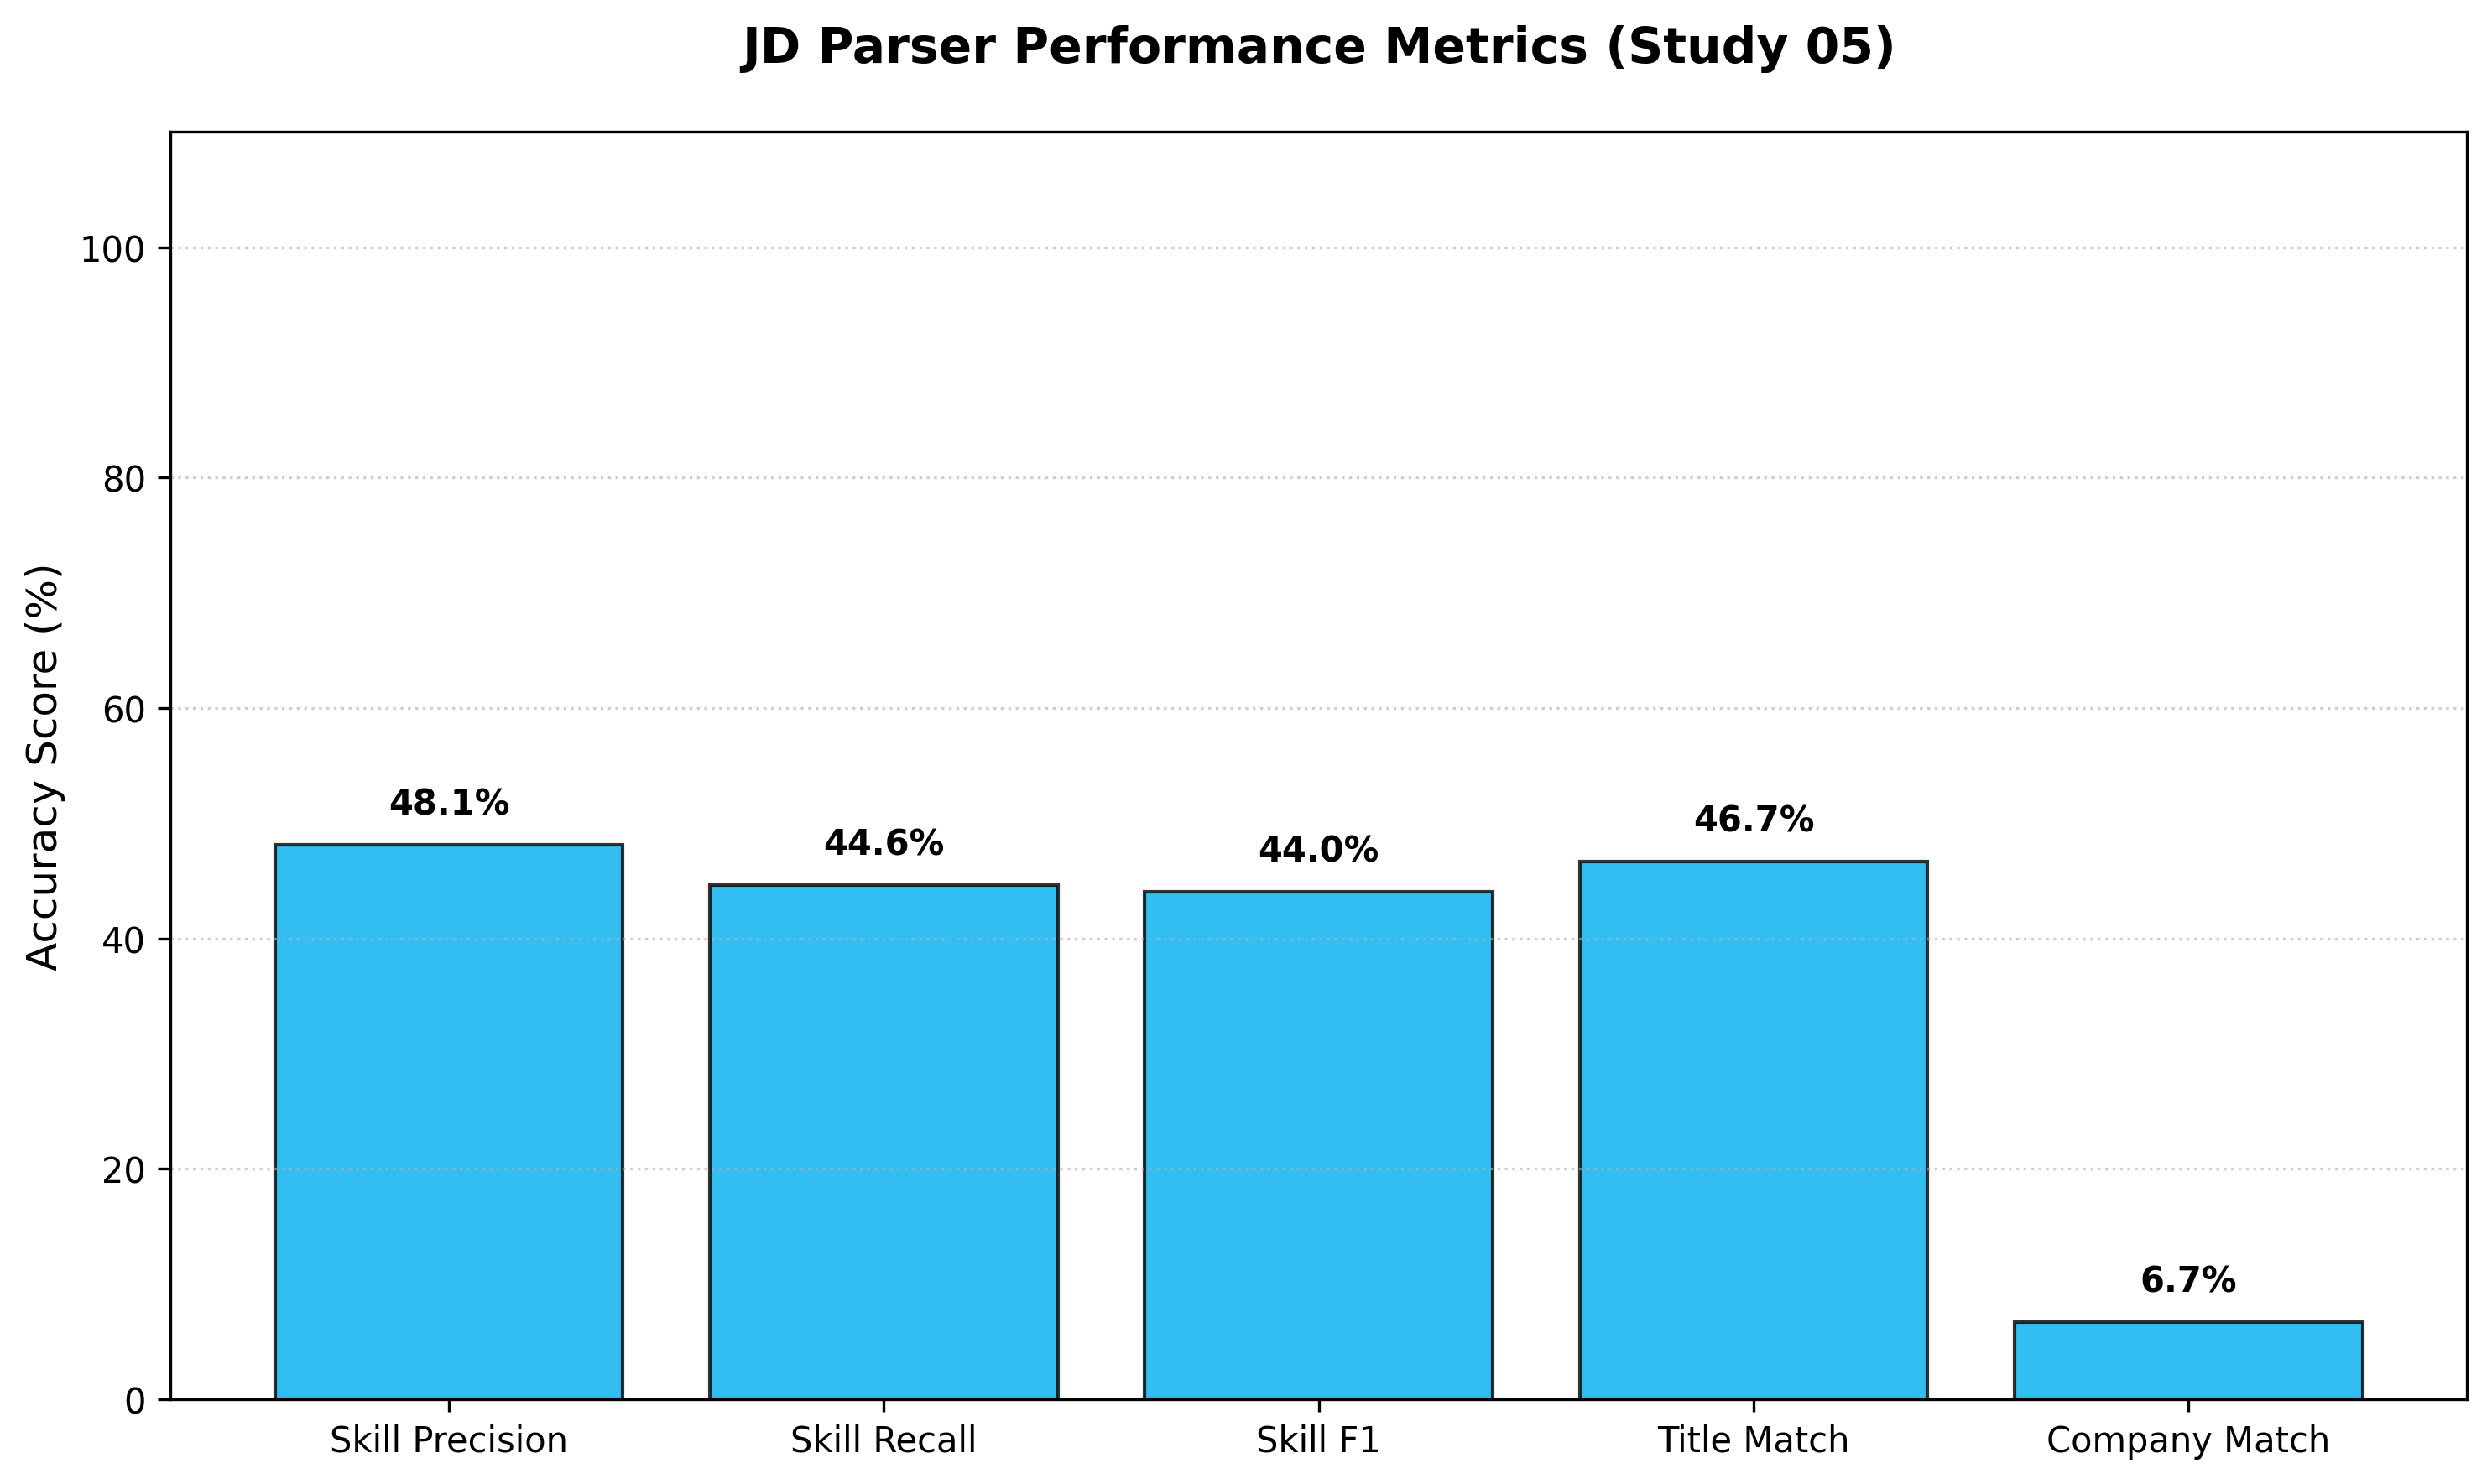

In [7]:
study_05_dir = os.path.join(root_dir, '05-jd_parser_test')

with working_directory(study_05_dir):
    print("Running JD Parser Accuracy Test...")

    from run_study import run_study_05
    run_study_05()

print("\nJD Parser Accuracy Metrics:")
display(Image(filename='05-jd_parser_test/output/jd_parser_accuracy.png', width=750))

## 6. Study 06: Adversarial Stress Testing
This study evaluates the robustness of the MERIT recruitment engine against adversarial gaming tactics, including keyword stuffing, identity hijacking (Smart Squatter), and metric inflation.

Running Adversarial Robustness Study...
Step 1: Generating Adversarial Data...
Generated 9 bare-bones adversarial profiles.

Step 2: Running Benchmarks...

--- Adversarial Benchmark Results ---
      Scenario          Candidate  ATS Score (CV Only)  MERIT Score (Multi-Source)  Delta
        Honest   Honest Candidate                34.44                       54.65  20.21
         Ghost          The Ghost                28.40                       36.52   8.12
         Fraud          The Fraud                34.44                       39.23   4.79
         Stale    Stale Candidate                39.85                       42.77   2.92
         Gamer  The Time Traveler                39.85                       62.98  23.13
      Squatter Squatter Candidate                34.44                       34.65   0.21
Smart_squatter Rayan Akhtar Smith                34.44                       54.65  20.21
        Shadow         The Shadow                34.44                       35.27   0

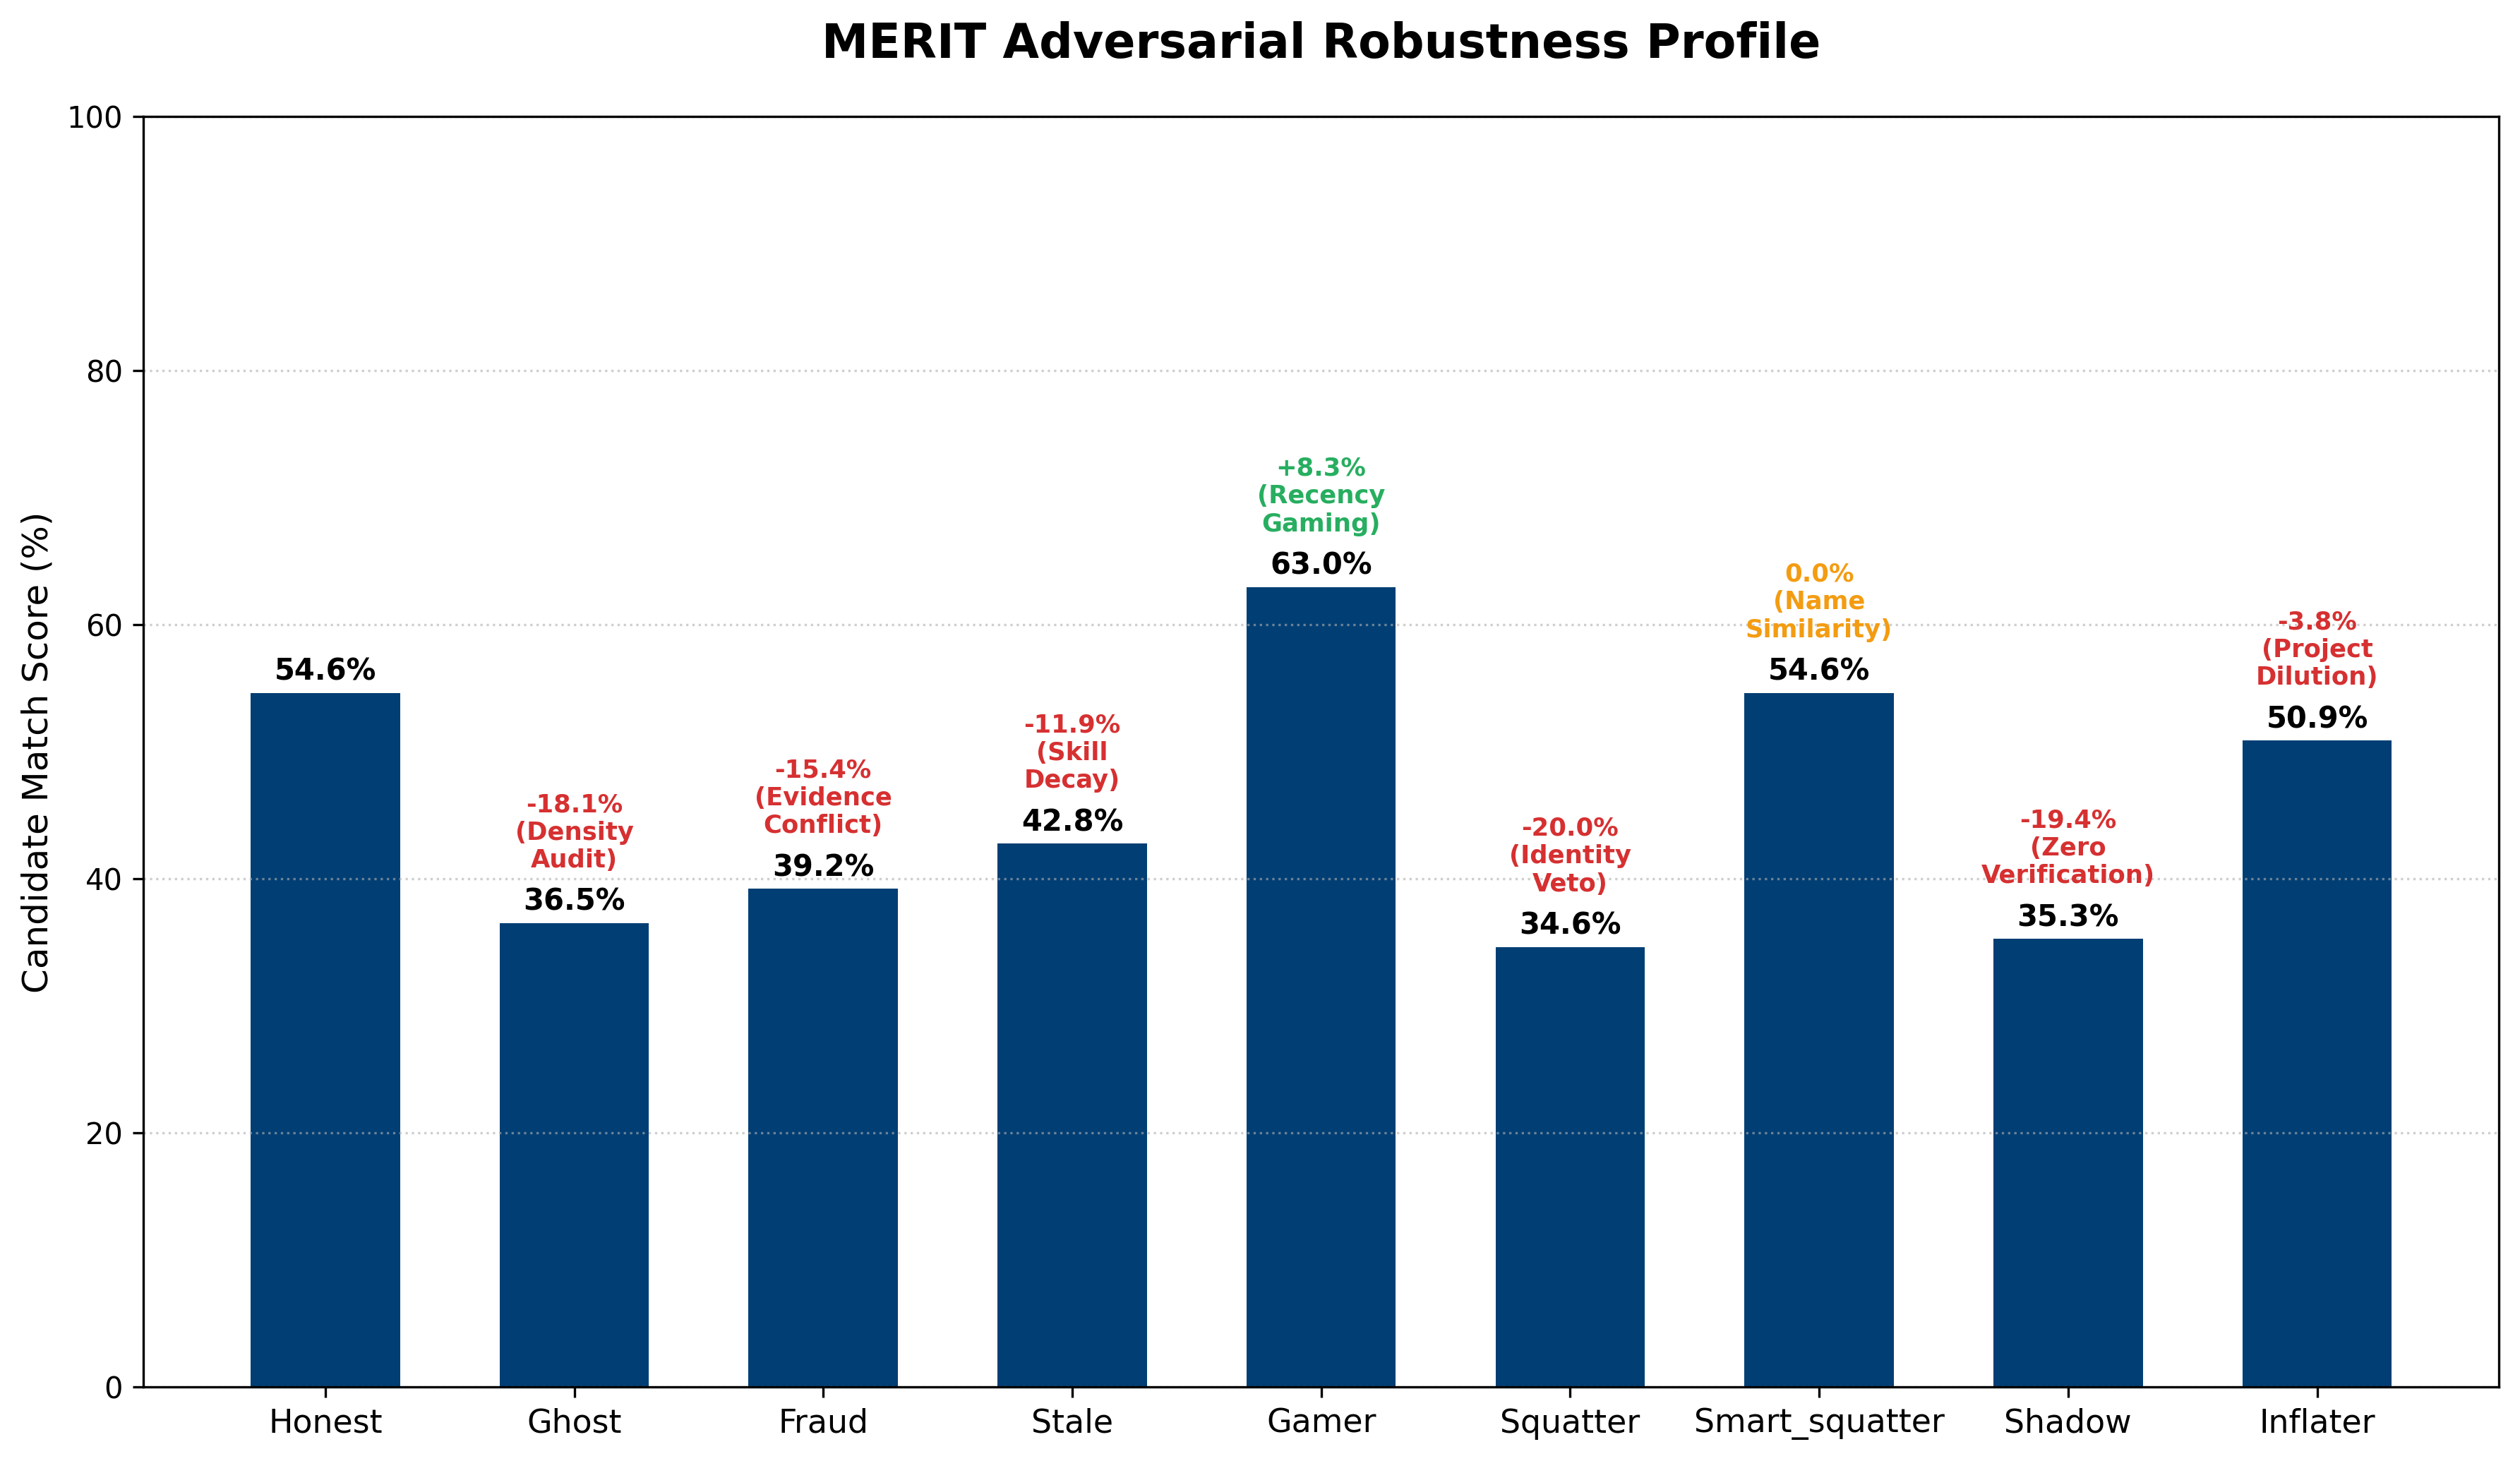

In [8]:
print("Running Adversarial Robustness Study...")
with working_directory('06-adversarial_test'):
    # Force reload of run_study to avoid collision with Study 05
    import sys
    import os
    if 'run_study' in sys.modules:
        del sys.modules['run_study']
    
    sys.path.insert(0, os.getcwd())
    from run_study import run_study_06
    run_study_06()

print("\nAdversarial Robustness Profile:")
display(Image(filename='06-adversarial_test/output/adversarial_robustness.png', width=900))

## 4. Spearman Rank Correlation Suite
This section validates the engine's ranking accuracy against expert human judgment using Spearman's Rho ($\rho$). We test four distinct scenarios to evaluate performance, bias, and robustness.


In [9]:
# Setup: Prepare candidate batches and apply sabotage for Study 10
import subprocess
import sys
import os

print("Preparing Spearman data batches...")
subprocess.run([sys.executable, "prepare_spearman_data.py"], check=True)
subprocess.run([sys.executable, "sabotage_study_10.py"], check=True)
print("Setup complete.")


Preparing Spearman data batches...
Setup complete.


### 4.1 Study 07: High Discrimination
Tests the ability to distinguish between Backend specialists and unrelated engineering domains (iOS, Android, Data Science).


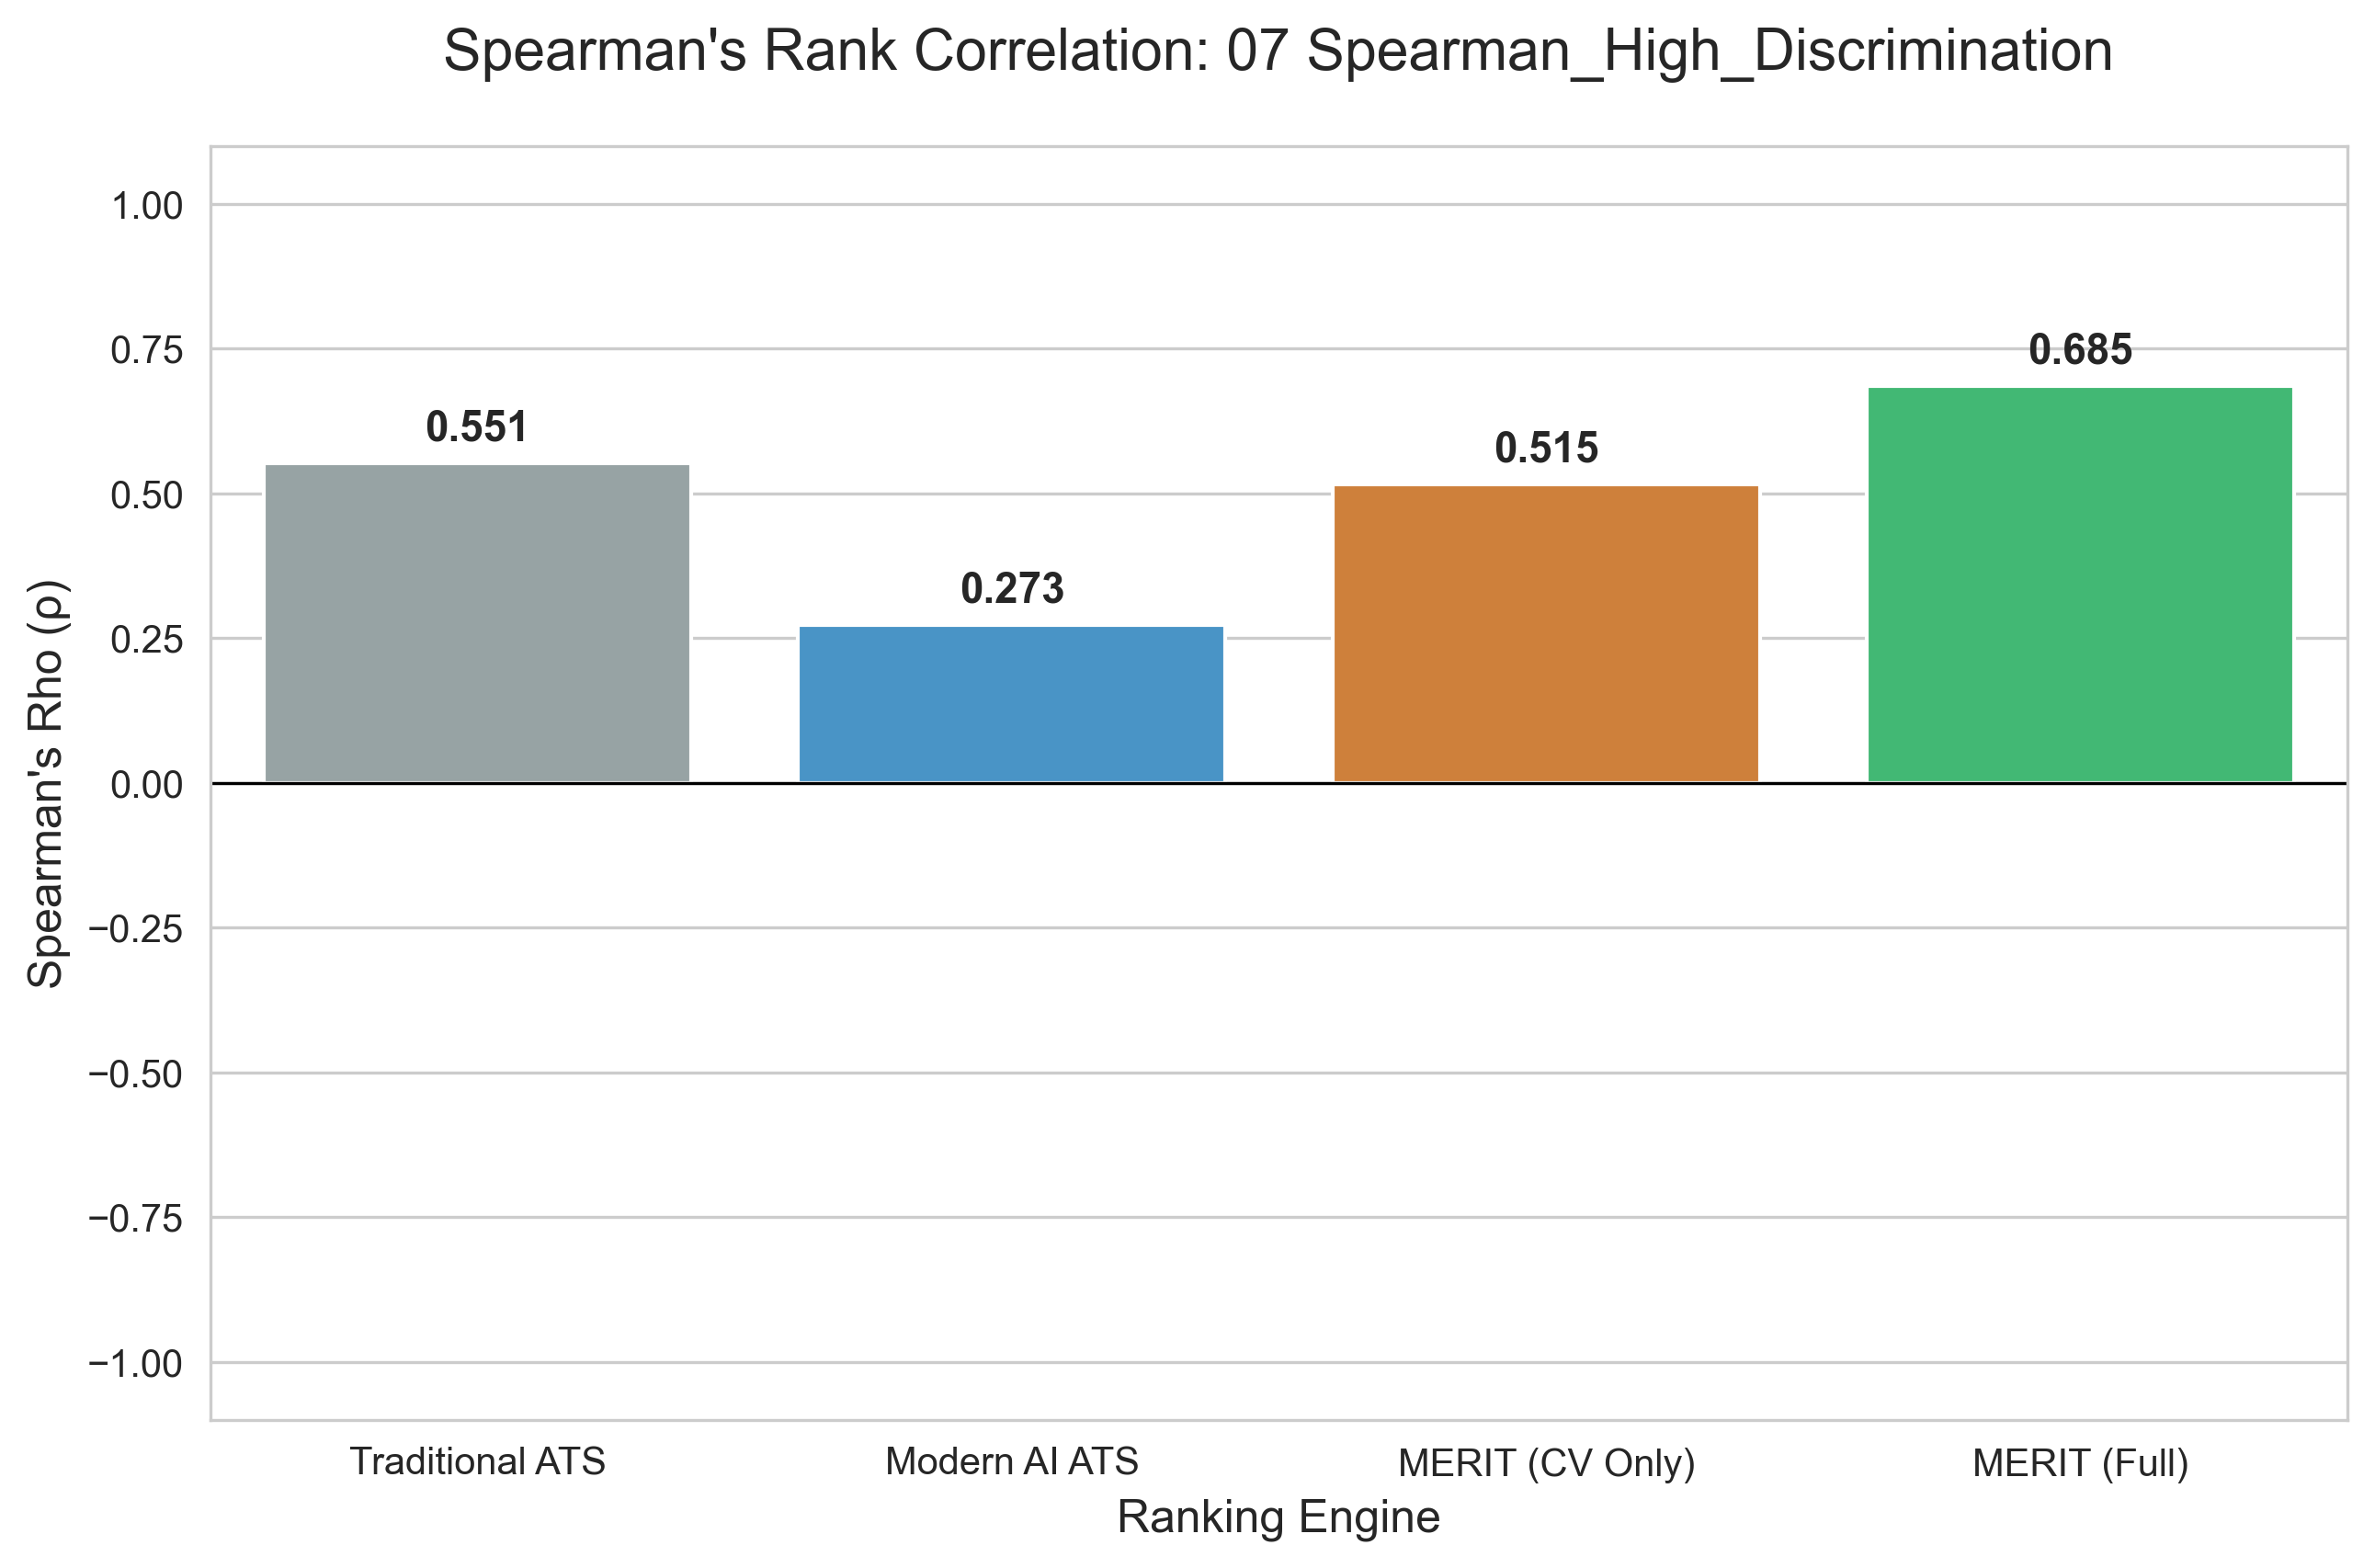

In [10]:
study_path = os.path.join(os.getcwd(), "07-spearman_high_discrimination")
with working_directory(study_path):
    subprocess.run([sys.executable, "run_study.py"], check=True)

display(Image(filename="07-spearman_high_discrimination/output/spearman_chart.png", width=900))


### 4.2 Study 08: Seniority Bias Audit
Tests if engines wrongly prioritize seniority (Principal Engineers) for an Intern-level role. Human ranking prioritizes the Intern.


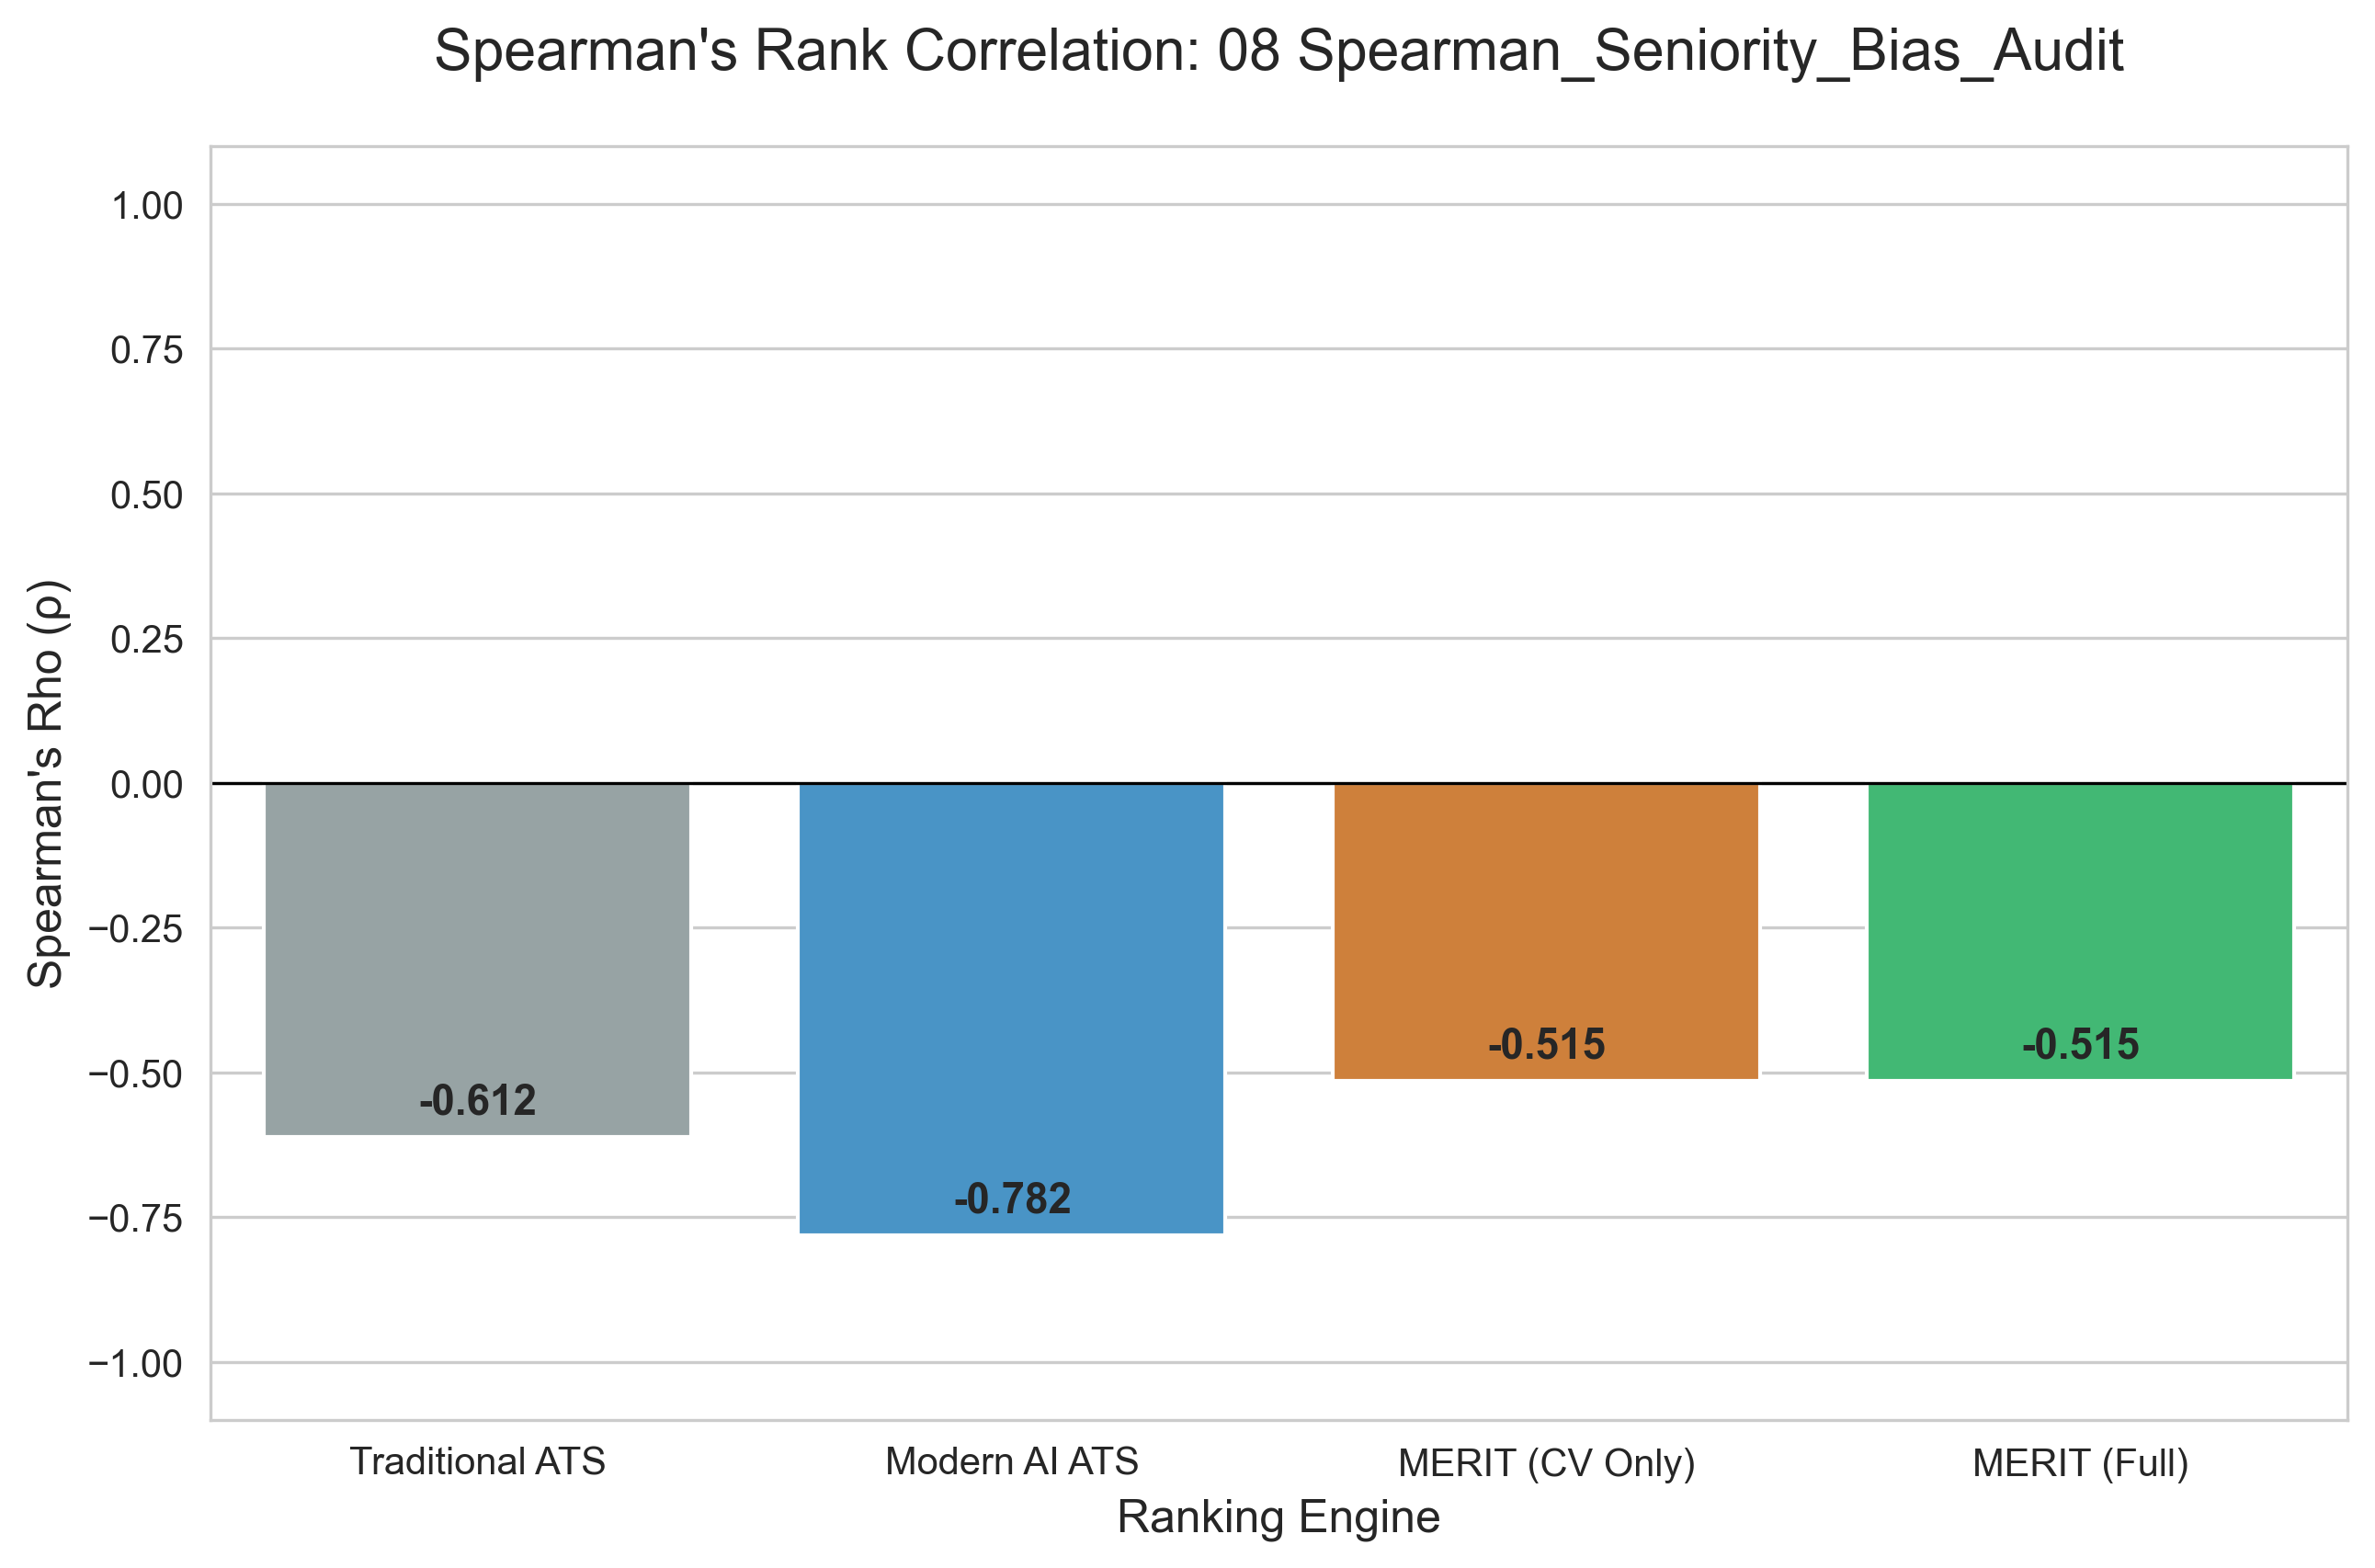

In [11]:
study_path = os.path.join(os.getcwd(), "08-spearman_seniority_bias_audit")
with working_directory(study_path):
    subprocess.run([sys.executable, "run_study.py"], check=True)

display(Image(filename="08-spearman_seniority_bias_audit/output/spearman_chart.png", width=900))


### 4.3 Study 09: Peer Competition
Tests technical discrimination among candidates of the same seniority (all Mid-Level) across different engineering specialties.


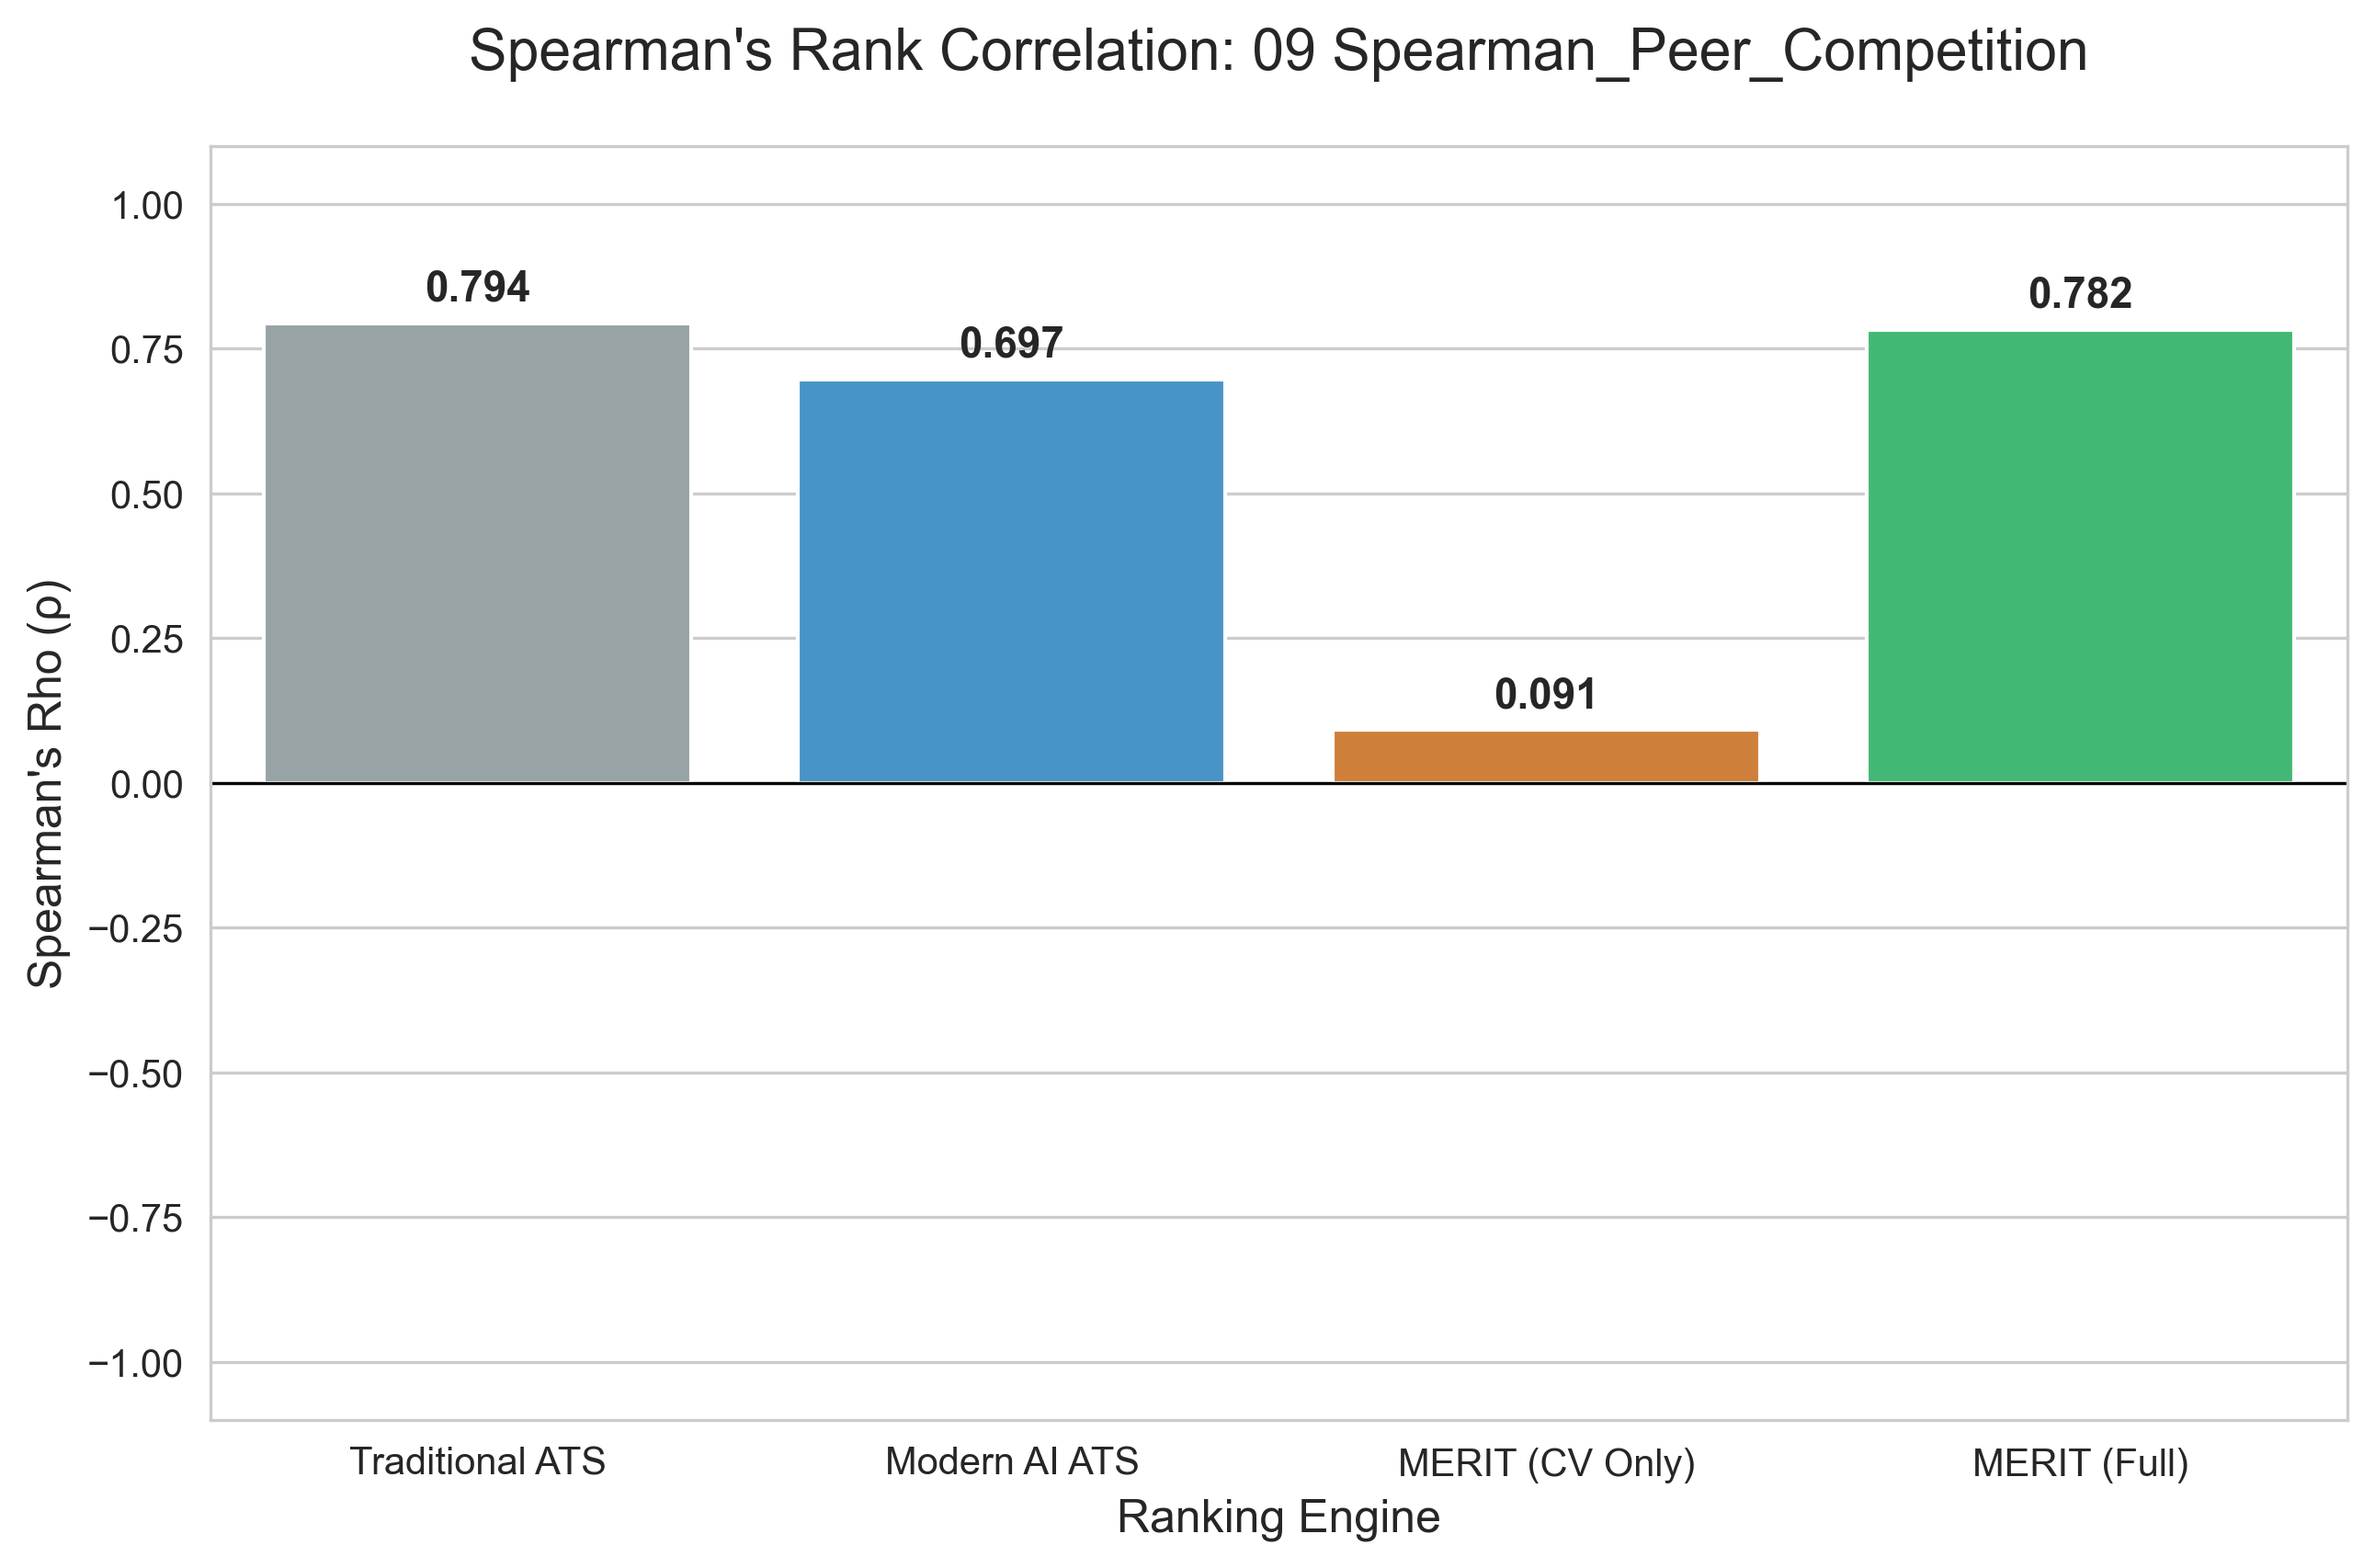

In [14]:
study_path = os.path.join(os.getcwd(), "09-spearman_peer_competition")
with working_directory(study_path):
    subprocess.run([sys.executable, "run_study.py"], check=True)

display(Image(filename="09-spearman_peer_competition/output/spearman_chart.png", width=900))


### 4.4 Study 10: Signal Dissonance (Sabotage Case)
A deliberate failure case where GitHub data is sabotaged to contradict the CV. Used to test engine sensitivity to data quality.


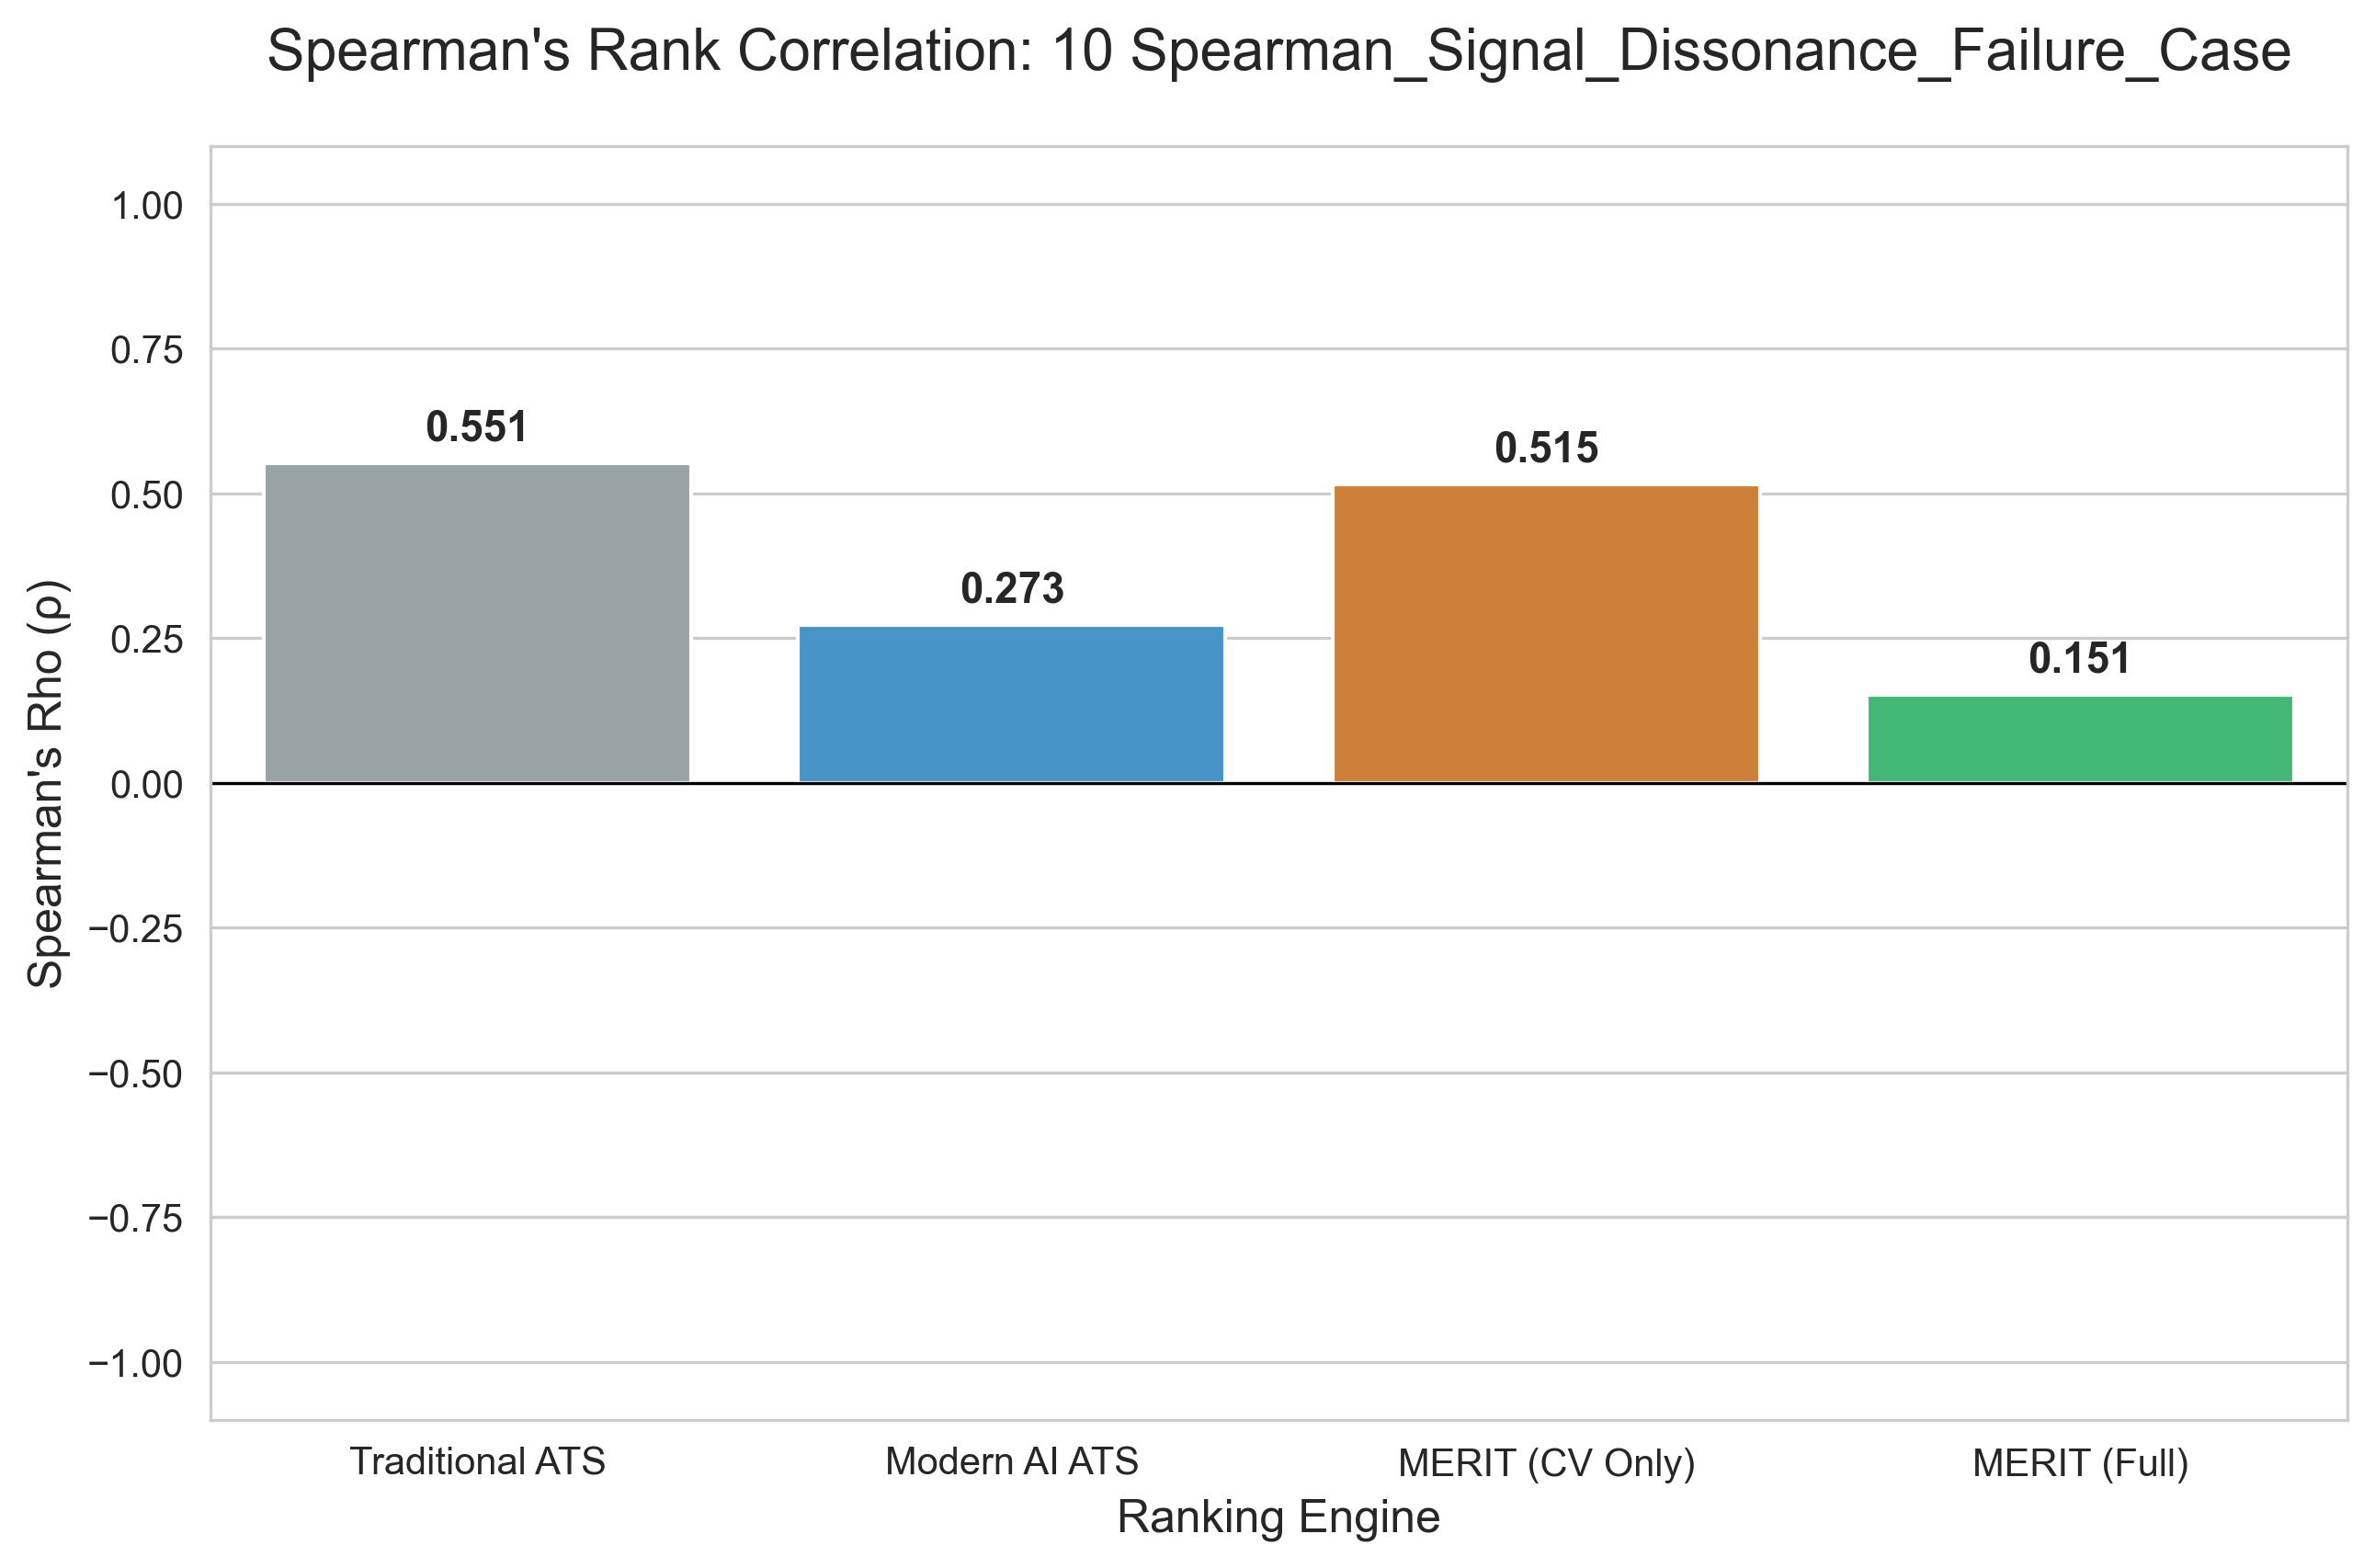

In [13]:
study_path = os.path.join(os.getcwd(), "10-spearman_signal_dissonance_failure_case")
with working_directory(study_path):
    subprocess.run([sys.executable, "run_study.py"], check=True)

display(Image(filename="10-spearman_signal_dissonance_failure_case/output/spearman_chart.png", width=900))
